# Анализ поведения пользователей мобильного приложения по продаже продуктов питания

<a id=content></a>
## Содержание
<br>[Описание проекта](#descr_proj)
<br>[Описание данных](#descr_data)
<br>
<br>[<b>Шаг 1. Открыть файл с данными и изучить общую информацию</b>](#1)
<br>[1.1. Загрузка данных](#1.1)
<br> 
<br>[<b>Шаг 2. Предварительная обработка данных</b>](#2)
<br>[2.1. Заменить названия столбцов на удобные для вас](#2.1.)
<br>[2.2. Проверить пропуски и типы данных. Откорректировать, если нужно](#2.2.)
<br>[2.3. Добавить столбец даты и времени, а также отдельный столбец дат](#2.3.)
<br>
<br>[<b>Шаг 3. Изучение и проверка данных</b>](#3)
<br>[3.1. Сколько всего событий в логе?](#3.1)
<br>[3.2. Сколько всего пользователей в логе?](#3.2)
<br>[3.3. Сколько в среднем событий приходится на пользователя?](#3.3)
<br>[3.4. Данными за какой период мы располагаем?](#3.4)
<br>[3.5. Можно ли быть уверенным, что у вас одинаково полные данные за весь период?](#3.5)
<br>[3.6. Определите, с какого момента данные полные и отбросьте более старые](#3.6)
<br>[3.7. Много ли событий и пользователей вы потеряли, отбросив старые данные?](#3.7)
<br>[3.8. Проверьте, что у вас есть пользователи из всех трёх экспериментальных групп](#3.8)
<br>[3.9. Оценка пользовательской активности и нагрузки на приложение](#3.9)
<br>
<br>[<b>Шаг 4. Изучение воронки событий</b>](#4)
<br>[4.1. Посмотрите, какие события есть в логах, как часто они встречаются. Отсортируйте события по частоте.](#4.1)
<br>[4.2. Посчитайте, сколько пользователей совершали каждое из этих событий. Отсортируйте события по числу пользователей. Посчитайте долю пользователей, которые хоть раз совершали событие.](#4.2)
<br>[4.3. Предположите, в каком порядке происходят события. Все ли они выстраиваются в последовательную цепочку? Их не нужно учитывать при расчёте воронки.](#4.3)
<br>[4.4. По воронке событий посчитайте, какая доля пользователей проходит на следующий шаг воронки (от числа пользователей на предыдущем). То есть для последовательности событий A → B → C посчитать отношение числа пользователей с событием B к количеству пользователей с событием A, а также отношение числа пользователей с событием C к количеству пользователей с событием B.](#4.4)
<br>[4.5. На каком шаге теряете больше всего пользователей?](#4.5)
<br>[4.6. Какая доля пользователей доходит от первого события до оплаты?](#4.6)
<br>
<br>[<b>Шаг 5. Изучение результатов эксперимента</b>](#5)
<br>[5.1. Сколько пользователей в каждой группе?](5.1)
<br>[5.2. Есть 2 контрольные группы для А/А-эксперимента, чтобы проверить корректность всех механизмов и расчётов. Проверьте, находят ли статистические критерии разницу между выборками 246 и 247.](#5.2)
<br>[5.3. Выберите самое популярное событие.](#5.3)
<br>[5.4. Посчитайте число пользователей, совершивших это событие в каждой из контрольных групп.](#5.4)
<br>[5.5. Посчитайте долю пользователей, совершивших это событие.](#5.5)
<br>[5.6. Проверьте, будет ли отличие между группами статистически достоверным.](#5.6)
<br>[5.7. Проделайте то же самое для всех других событий (удобно обернуть проверку в отдельную функцию). Можно ли сказать, что разбиение на группы работает корректно?](#5.7)
<br>[5.8. Аналогично поступите с группой с изменённым шрифтом. Сравните результаты с каждой из контрольных групп в отдельности по каждому событию.](#5.8)
<br>[5.9. Сравните результаты с объединённой контрольной группой. Какие выводы из эксперимента можно сделать?](#5.9)
<br>[5.10.Какой уровень значимости вы выбрали при проверке статистических гипотез выше?](#5.10)
<br>[5.11. Посчитайте, сколько проверок статистических гипотез вы сделали. При уровне значимости 0.1 каждый десятый раз можно получать ложный результат. Какой уровень значимости стоит применить?](#5.11)
<br>[5.12. Если вы хотите изменить его, проделайте предыдущие пункты и проверьте свои выводы.](#5.12)
<br>
<br>[<b>Шаг 6. Выводы</b>](#6)
<br>
<br>[<b>Список источников и литературы</b>](#7)
<br>
<br>[к содержанию](#content) | [шаг 1](#1) | [шаг 2](#2) | [шаг 3](#3) | [шаг 4](#4) | [шаг 5](#5) | [шаг 6](#6) 

<a id=descr_proj></a>
## Описание проекта

<br>Вы работаете в стартапе, который продаёт продукты питания. Нужно разобраться, как ведут себя пользователи вашего мобильного приложения. Изучите воронку продаж. Узнайте, как пользователи доходят до покупки. Сколько пользователей доходит до покупки, а сколько — «застревает» на предыдущих шагах? На каких именно?
<br>После этого исследуйте результаты A/A/B-эксперимента. Дизайнеры захотели поменять шрифты во всём приложении, а менеджеры испугались, что пользователям будет непривычно. Договорились принять решение по результатам A/A/B-теста. Пользователей разбили на 3 группы: 2 контрольные со старыми шрифтами и одну экспериментальную — с новыми. Выясните, какой шрифт лучше.
<br>Создание двух групп A вместо одной имеет определённые преимущества. Если две контрольные группы окажутся равны, вы можете быть уверены в точности проведенного тестирования. Если же между значениями A и A будут существенные различия, это поможет обнаружить факторы, которые привели к искажению результатов. Сравнение контрольных групп также помогает понять, сколько времени и данных потребуется для дальнейших тестов.
<br>В случае общей аналитики и A/A/B-эксперимента работайте с одними и теми же данными. В реальных проектах всегда идут эксперименты. Аналитики исследуют качество работы приложения по общим данным, не учитывая принадлежность пользователей к экспериментам.

<a id=descr_data></a>
## Описание данных
Исходный датафрейм `logs_exp.csv` является лог-файлом, содержащим информацию о действиях пользователей данного мобильного приложения. Следовательно, каждая строка в логе хранит данные либо о действиях пользователя, либо о событиях в количестве 244 126 срок на 4 столбца.

|№ п/п|Наименование признака|Описание признака|Ед.|Размах значений признака|
|-----|:--------------------|:----------------|:--|:-----------------------|
|1.|`EventName`     |наименование события|`MainScreenAppear` - просмотр главной страницы, `PaymentScreenSuccessful` - просмотр страницы «Оплата прошла успешно», `CartScreenAppear` - просмотр страницы «Карточка товара», `OffersScreenAppear` - просмотр страницы «Каталог товаров», `Tutorial` - просмотр обучающего урока|5 уникальных наименований типов события|
|2.|`DeviceIDHash`  |хэш устройства|строка цифр и букв, сгенерированная устройством по запросу ПО с информацией об устройстве и его пользователе|7551 уникальный id устройств|
|3.|`EventTimestamp`|время события|секунды|от 1564029816 до 1565212517|
|4.|`ExpId`         |номер эксперимента: 246 и 247 — контрольные группы, а 248 — экспериментальная.|порядковый номер экспериментальной группы|от 246 до 248|

Данные получены посредством последовательного применения методов `len()`, `unique()`, `min()`, `max()` к вышеперечисленным датафреймам.

[к содержанию](#content) | [шаг 1](#1) | [шаг 2](#2) | [шаг 3](#3) | [шаг 4](#4) | [шаг 5](#5) | [шаг 6](#6) 

<a id=1></a>
## Шаг 1. Загрузка данных и получение общей информации

<a id=1.1></a>
### 1.1. Загрузка данных

In [1]:
# импорт библиотек
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from plotly import graph_objects as go
from datetime import datetime, timedelta
from scipy import stats as st
import datetime as dt
import math as mth

# устанавливаем опцию вывода всех столбцов
pd.set_option('display.max_columns', None)

# устанавливаем опцию вывода максимальной ширины столбцов
pd.set_option('display.max_colwidth', None)

# устанавливаем форматирование отображения чисел типа float с двумя знаками после запятой
pd.options.display.float_format ='{:.2f}'.format

# игнорирование системных предупреждений об обновлениях работы функций
import warnings
warnings.simplefilter('ignore')

# настройка вывода визуализации
%matplotlib inline

In [2]:
# загрузка файла в датафрейм
try:
    df_raw = pd.read_csv('logs_exp.csv', sep='\t')
except:
    df_raw = pd.read_csv('https://code.s3.yandex.net/datasets/logs_exp.csv', sep='\t')

In [3]:
# выводим датафрейм для ознакомления
df_raw.head()

,EventName,DeviceIDHash,EventTimestamp,ExpId
0,MainScreenAppear,4575588528974610257,1564029816,246
1,MainScreenAppear,7416695313311560658,1564053102,246
2,PaymentScreenSuccessful,3518123091307005509,1564054127,248
3,CartScreenAppear,3518123091307005509,1564054127,248
4,PaymentScreenSuccessful,6217807653094995999,1564055322,248


In [4]:
# выводим основную информацию о количестве записей, количестве ненулевых значений, типах признаков
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244126 entries, 0 to 244125
Data columns (total 4 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   EventName       244126 non-null  object
 1   DeviceIDHash    244126 non-null  int64 
 2   EventTimestamp  244126 non-null  int64 
 3   ExpId           244126 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 7.5+ MB


In [5]:
# выводим первичный статистический анализ по заказам и посетителям
df_raw.describe()

,DeviceIDHash,EventTimestamp,ExpId
count,244126.00,244126.00,244126.00
mean,4627568124591259648.00,1564913915.84,247.02
std,2642424998963707904.00,177134.32,0.82
min,6888746892508752.00,1564029816.00,246.00
25%,2372212476992240640.00,1564756580.25,246.00
50%,4623191541214045184.00,1564919395.00,247.00
75%,6932517045703054336.00,1565074511.00,248.00
max,9222603179720523776.00,1565212517.00,248.00


**Выводы:** на этом этапе нами был импортирован ряд библиотек, в том числе `pandas` для работы с массивами данных, `matplotlib` и `seaborn` для визуализации полученных результатов.

Осуществлена загрузка исходных данных методом `read_csv`. В работу поступил лог-файл `logs_exp.csv`, содержащий информацию о действиях пользователей данного мобильного приложения. На основании результатов последовательного применения методов `min()`, `max()`, `unique()`, `info()` и `describe()`, а также цепочки методов `isna().sum()` и `duplicated().sum()` мы получили первичную информацию для статистического анализа. 

[к содержанию](#content) | [шаг 1](#1) | [шаг 2](#2) | [шаг 3](#3) | [шаг 4](#4) | [шаг 5](#5) | [шаг 6](#6) 

<a id=2></a>
## Шаг 2. Предварительная обработка данных

<a id=2.1></a>
### 2.1. Переименование названий признаков

In [6]:
# приведём наименования признаков к змеиному регистру
df_raw = df_raw.rename(columns={'EventName':'event_name', 
                                'DeviceIDHash':'device_id', 
                                'EventTimestamp':'event_date', 
                                'ExpId':'exp_id'})

In [7]:
# выводим наименования признаков для ознакомления с результатами преобразований
df_raw.columns

Index(['event_name', 'device_id', 'event_date', 'exp_id'], dtype='object')

<a id=2.2></a>
### 2.2. Проверить пропуски, дубликаты и преобразовать типы данных, при необходимости откорректировать

In [8]:
# подсчитаем количество пропущенных значений в датафрейме
df_raw.isna().sum()

event_name    0
device_id     0
event_date    0
exp_id        0
dtype: int64

In [9]:
# расчёт количества и процентажа дубликатов
print('Всего в датафрейме', df_raw.duplicated().sum(), 'дубликатов, что в % составляет', 
      (df_raw.duplicated().sum() / len(df_raw)).round(3), 'от общего количества строк.')

Всего в датафрейме 413 дубликатов, что в % составляет 0.002 от общего количества строк.


In [10]:
# удаление дубликатов
df_clr = df_raw.drop_duplicates().reset_index(drop=True)
df_clr.shape

(243713, 4)

In [11]:
# проверка одновременного присутствия пользователей в двух и более группах
df_clr.groupby('device_id')['exp_id'].nunique().reset_index().query('exp_id > 1')

,device_id,exp_id


Одновременное присутствие пользователей в двух и более группах не выявлено.

In [12]:
# преобразование типа данных `datetime`
df_clr['event_date'] = pd.to_datetime(df_clr['event_date'], unit='s')

<a id=2.3></a>
### 2.3. Добавить столбец даты и времени, а также отдельный столбец дат

In [13]:
# создаём признак, хранящий дату события
df_clr['date'] = pd.to_datetime(df_clr['event_date'].dt.date)

In [14]:
#  пересобираем датафрейм в смысловом порядке значений признаков
df_clr = df_clr[['exp_id', 'device_id', 'event_name', 'event_date', 'date']]

In [15]:
# актуальный размер датафрейма
df_clr.shape

(243713, 5)

**Вывод:** выполнена предварительная обработка данных. Названия признаков были приведены к нижнему регистру методом `rename()`. Установлено отсутствие пропусков, выявлены и удалены дубликаты в количестве 413 строк. Выполнена проверка на одновременное присутствие пользователей в нескольких группах тестирования, установлено, что трафик разделён равномерно, пересечения данных отсутствуют. Выполнено преобразование типа данных признака даты, время в формате unix преобразовано методом `pd.to_datetime`. Создан дополнительный признак `date`, хранящий информацию о дате события.
<br>По итогам предвартельной обработки данных массив приобрёл размер 243713 строк на 5 столбцов. На этом этапе потери в данных составили 413 строк или 0.002%.

[к содержанию](#content) | [шаг 1](#1) | [шаг 2](#2) | [шаг 3](#3) | [шаг 4](#4) | [шаг 5](#5) | [шаг 6](#6) 

<a id=3></a>
## Шаг 3. Изучение и проверка данных

<a id=3.1></a>
### 3.1. Сколько всего событий в логе?

In [16]:
# количество типов событий в логе
print('Всего типов событий в логе:', df_clr['event_name'].nunique())

# количество событий в логе в разрезе каждого типа
df_clr.groupby('event_name').agg({'event_name': 'count'})

Всего типов событий в логе: 5


,event_name
event_name,
CartScreenAppear,42668
MainScreenAppear,119101
OffersScreenAppear,46808
PaymentScreenSuccessful,34118
Tutorial,1018


**Вывод:** в актуальном датафрейме присутствуют 5 типов событий, а именно:
1. MainScreenAppear - просмотр главной страницы;
2. OffersScreenAppear - просмотр каталога товаров;
3. CartScreenAppear - просмотр карточки товара;
4. PaymentScreenSuccessful - просмотр страницы «Оплата прошла успешно», то есть пользователь успешно оплатил заказ;
5. Tutorial - просмотр обучающего урока взаимодействия с приложением.

Всего в логе `df_clr` зафиксировано 243 713 событий. Ожидаемо, самое массовое событие - просмотр главной страницы (более 110 000 строк), а самое редкое - обучение взаимодействию с приложением (около 1000 строк). 

<a id=3.2></a>
### 3.2. Сколько всего пользователей в логе?

In [17]:
# количество пользоваетелей в логе
print('Всего пользователей в логе:', df_clr['device_id'].nunique())

Всего пользователей в логе: 7551


In [18]:
# количество пользователей в разерезе групп, а также количество строк данных в разрезе групп
df_clr.groupby('exp_id').agg({'device_id': ('nunique', 'count')})

device_id       
         nunique  count
exp_id                 
246         2489  80181
247         2520  77950
248         2542  85582

**Вывод:** общее количество пользователей в логе составляет 7 551 человек, в том числе в тестовой группе №246 - 2489 человек, в группе №247 - 2520 человек, а в группе №248 - 2542 человек. Активность пользователей во всех трёх группах тестирования представлена почти равномерно, численное преимущество - за пользователями группы тестовой №248, количество их строк составляет 85882, чуть меньше записей у пользователей тестовой группы №246 - 80181 строка, отрыв в почти 8000 строк отмечается с пользователями тестовой группы №246.

<a id=3.3></a>
### 3.3. Сколько в среднем событий приходится на пользователя?

In [19]:
# расчёт среднего количества событий на пользователя
df_clr.shape[0] / df_clr['device_id'].nunique()

32.27559263673685

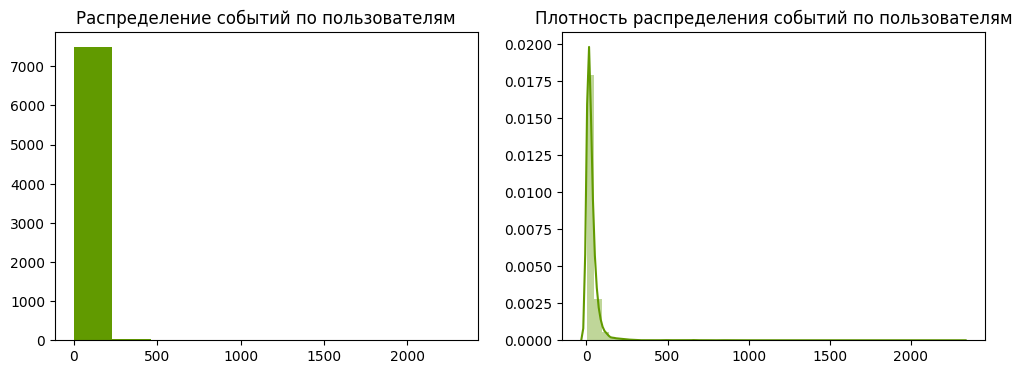

In [20]:
# парные диаграммы для количества событий на пользователя
plt.figure(figsize=(12,3))

events_by_user = df_clr.groupby('device_id').agg(event_count = ('event_name', 'count')).reset_index()

plt.subplot(1,2,1)
plt.title('Распределение событий по пользователям')
events_by_user['event_count'].hist(figsize=(12,4), grid=False, color='#619A00').set(ylabel = '', xlabel = '')

plt.subplot(1,2,2)
plt.title('Плотность распределения событий по пользователям')
sns.distplot(events_by_user['event_count'], color = '#619A00').set(ylabel = '', xlabel = '')

plt.show()

In [21]:
# первичная описательная статистика количества событий на пользователя
print(events_by_user['event_count'].describe())
print('Медианное значение: ', events_by_user['event_count'].median())

# перцентили количества событий на одного пользователя
print('Q95 событий на пользователя', np.percentile(events_by_user['event_count'], [95]))
print('Q99 событий на пользователя', np.percentile(events_by_user['event_count'], [99]))
print('Аномальных пользователей с порогом выше Q99:', len(events_by_user[events_by_user['event_count'] > 200]))

count   7551.00
mean      32.28
std       65.15
min        1.00
25%        9.00
50%       20.00
75%       37.00
max     2307.00
Name: event_count, dtype: float64
Медианное значение:  20.0
Q95 событий на пользователя [89.]
Q99 событий на пользователя [200.5]
Аномальных пользователей с порогом выше Q99: 76


Мы можем рассмотреть диаграммы подробнее, сделав срез данных по аномальным пользователям с количеством событий более 200:

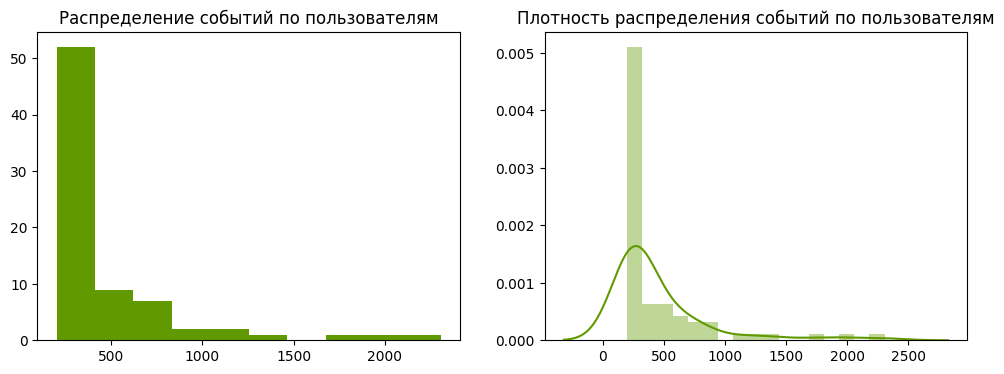

In [22]:
# парные диаграммы для количества событий на пользователя
plt.figure(figsize=(12,4))

events_by_user1 = events_by_user.query('event_count > 200')

plt.subplot(1,2,1)
plt.title('Распределение событий по пользователям')
events_by_user1['event_count'].hist(grid=False, color='#619A00').set(ylabel = '', xlabel = '')

plt.subplot(1,2,2)
plt.title('Плотность распределения событий по пользователям')
sns.distplot(events_by_user1['event_count'], color = '#619A00').set(ylabel = '', xlabel = '')

plt.show()

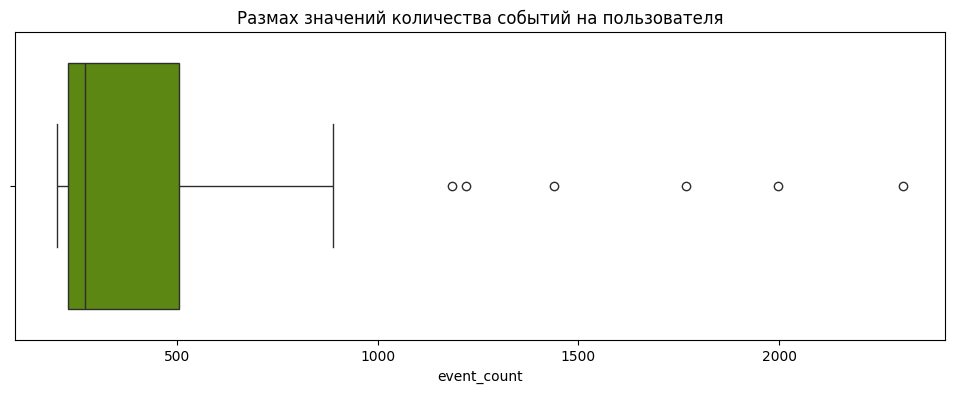

In [23]:
# диаграмма размаха значений признака
plt.figure(figsize=(12,4))
plt.title('Размах значений количества событий на пользователя')
sns.boxplot(data=events_by_user1, x=events_by_user1['event_count'], color = '#619A00');

**Вывод:** на гистограмме распределения событий по пользователям  мы видим всплеск значений в пределах 200 единиц. РАссчитанное среднее значение количества событий на пользователя равно 32, при этом медиана этого признака составляет 20 событий на человека. Столько же  действий совершает половина пользователей лога. Абсолютное большинство пользователей (до 95% аудитории) совершают порядка 89-90 действий в приложении, а вот свыше 200 событий является редким исключением. Таких пользователей на весь лог набралось всего 76 человек - это настоящие фанаты приложения.

<a id=3.4></a>
### 3.4. Данными за какой период мы располагаем?

Найти максимальную и минимальную дату. Построить гистограмму по дате и времени.

In [24]:
# хронологические рамки исследования, имеющиеся в исходных данных 
df_clr['date'].describe()[4:]

50%    2019-08-04 00:00:00
75%    2019-08-06 00:00:00
max    2019-08-07 00:00:00
Name: date, dtype: object

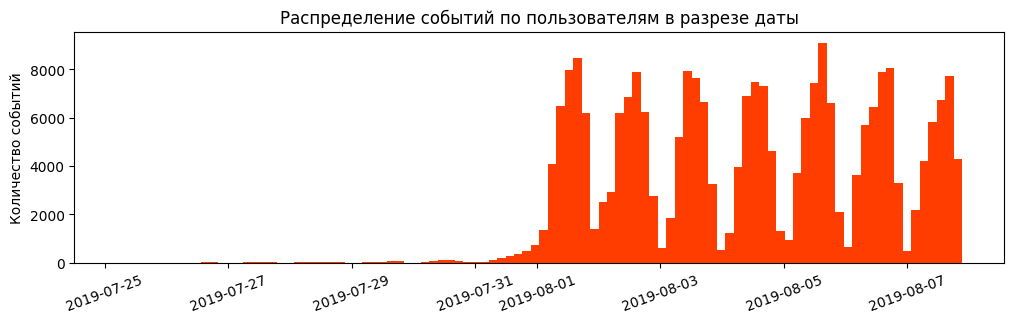

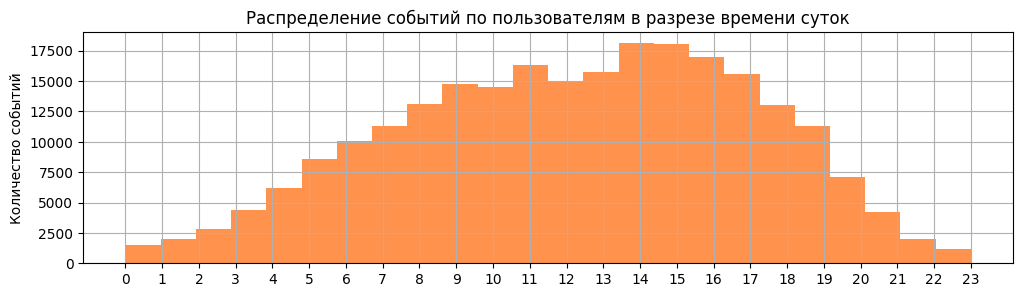

In [25]:
# гистограмма активности пользователей в разрезе даты
plt.figure(figsize=(12,3))
plt.title('Распределение событий по пользователям в разрезе даты')
df_clr['event_date'].hist(grid=False, color='#FF3D00', bins=100, xrot=20).set(ylabel = 'Количество событий', xlabel = '')

# гистограмма активности пользователей в разрезе времени суток
plt.figure(figsize=(12,3))
plt.title('Распределение событий по пользователям в разрезе времени суток')
df_clr['event_date'].dt.hour.hist(grid=False, color='#FF6400', bins=24, alpha=0.7).set(ylabel = 'Количество событий', xlabel = '')
plt.grid(True)
plt.xticks(range(0, 24))
plt.show()

**Вывод:** на основании информации датафрейма `df_clr`, полученной методом `describe`, а также с помощью гистограммы нами сформированы данные о распределении количества событий на отрезке времени с с 25 июля по 7 августа 2019 года включительно. Установлен факт неравномерного распределения хронологических данных: значения признкак на отрезке с 25 по 31 июля 2019 года включительно присутствуют в минимальных количествах. Во избежание искажения результатов A/A/B-теста представляется необходимым исключить из анализа вышеуказанный отрезок времени.

Также установлен период пиковой активности пользователей в течение суток: 13.30 - 15.20. Очевидно, это нормированное время обеденного перерыва, в который многие предпочитают совместить несколько форм отдыха, в том числе, посещение данного приложения. Второй по пользовательской активности период приходится на отрезок с 7.50 до 13.30. Это большой временной период, на котором с 9 утра идёт стабильное высокое присутствие пользователей в приложении. Прирост на 2500 пользователей отмечается только на следующем пике максимального роста. Падение активности пользователей отмечается на интервале с 15.20 до 21 часа. Минимальная нагрузка на приложение на уровне одномоментного присутсвия 2300 пользователей приходится на временной интервал с 21 до 2 часов ночи, и с этого момента он только увеличивается. 

<a id=3.5></a>
### 3.5. Проверка данных на одинаковую полноту во всех периодах

Технически в логи новых дней по некоторым пользователям могут «доезжать» события из прошлого — это может «перекашивать данные».

In [26]:
# применим метод intersection, который вернёт пересечение индексов элементов, общих для обоих массивов данных
jul = set(df_clr[df_clr['event_date'] <= '2019-07-31']['device_id'])
aug = set(df_clr[df_clr['event_date'] >= '2019-08-01']['device_id'])
julaug = jul.intersection(aug)
len(julaug)

544

In [27]:
# исключаем из анализа пользователей, действия которых отмечены и в июле, и в августе 2019 года
df = df_clr[~df_clr['device_id'].isin(julaug)]
df.shape

(228451, 5)

**Вывод:** с помощью метода `.intersection()` нами было установлено, что 544 пользователя присутствуют своими цифровыми следами и в июле, и в августе 2019 года. Ранее нами было принято решение об исключении из анализа данных вплоть до 31 июля 2019 года. Следовательно, в целях избежания искажения данных после вышеуказанной фильтрации, нами было принято решение об исключении таких пользователей из оставшегося массива данных с 1 по 7 августа 2019 года.

<a id=3.6></a>
### 3.6. Определите, с какого момента данные полные и отбросьте более старые

Данными за какой период времени мы располагаем на самом деле?

In [28]:
# срез данных по временному порогу 1 августа 2019 года
df = df[df['event_date'] >= '2019-08-01']

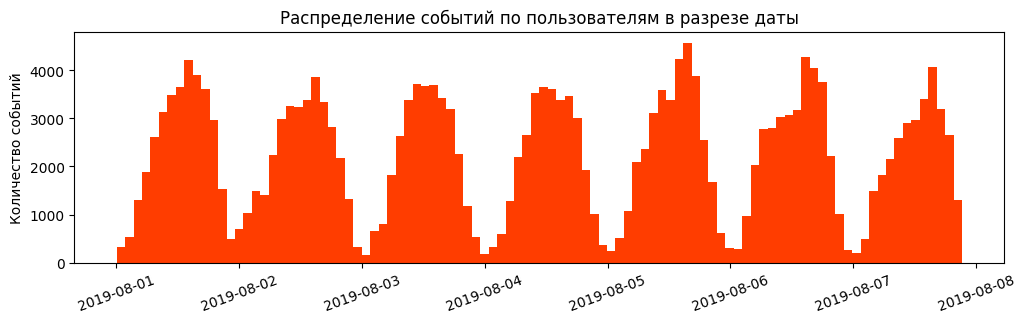

In [29]:
# визуализация распределения временных данных после среза
plt.figure(figsize=(12,3))
plt.title('Распределение событий по пользователям в разрезе даты')
df['event_date'].hist(grid=False, color='#FF3D00', bins=100, xrot=20).set(ylabel = 'Количество событий', xlabel = '');

**Вывод:** нормальное распределение данных присутсвует на временном отрезке с 1 по 7 августа 2019 года включительно. По итогам фильтрации данных на временном отрезке с 1 по 7 августа 2019 года нами был создан новый датафрейм `df`.

<a id=3.7></a>
### 3.7. Много ли событий и пользователей вы потеряли, отбросив старые данные?

In [30]:
# подсчитаем число потерь пользователей от исходных к актуальным данным
print('Потери по количеству пользователей от исходных данных в количестве', 
      df_clr['device_id'].nunique(), 'человек к актуальным данным в количестве', 
      df['device_id'].nunique(), 'человек составили', df_clr['device_id'].nunique() - 
      df['device_id'].nunique() , 'человек.')

Потери по количеству пользователей от исходных данных в количестве 7551 человек к актуальным данным в количестве 6990 человек составили 561 человек.


In [31]:
# потери в данных по событиям
df_ev = df_clr.groupby('event_name').agg(count_un_event = ('event_name','count')).reset_index()
diff = df_ev.merge(df.groupby('event_name').\
                                           agg(count_events_after = ('event_name','count')).reset_index())
diff.columns = ['event_name', 'raw data', 'filtered data']
diff['data_loss'] = diff['filtered data'] - diff['raw data']
diff

,event_name,raw data,filtered data,data_loss
0,CartScreenAppear,42668,40137,-2531
1,MainScreenAppear,119101,108849,-10252
2,OffersScreenAppear,46808,44419,-2389
3,PaymentScreenSuccessful,34118,32133,-1985
4,Tutorial,1018,1001,-17


In [32]:
# потери в данных по пользователям в группах по количеству пользователей
df_dev = df_clr.groupby('exp_id').agg(count_un_device = ('device_id','nunique')).reset_index()
diffdev = df_dev.merge(df.groupby('exp_id').\
                                           agg(count_device_after = ('device_id','nunique')).reset_index())
diffdev.columns = ['exp_id', 'raw data', 'filtered data']
diffdev['data_loss'] = diffdev['filtered data'] - diffdev['raw data']
diffdev

,exp_id,raw data,filtered data,data_loss
0,246,2489,2303,-186
1,247,2520,2336,-184
2,248,2542,2351,-191


In [33]:
# потери в данных по пользователям в группах по количеству строк по пользователям
df_dev = df_clr.groupby('exp_id').agg(count_un_device = ('device_id','count')).reset_index()
diffdev_raws = df_dev.merge(df.groupby('exp_id').\
                                           agg(count_device_after = ('device_id','count')).reset_index())
diffdev_raws.columns = ['exp_id', 'raw data', 'filtered data']
diffdev_raws['data_loss'] = diffdev_raws['filtered data'] - diffdev_raws['raw data']
diffdev_raws

,exp_id,raw data,filtered data,data_loss
0,246,80181,75241,-4940
1,247,77950,71699,-6251
2,248,85582,79599,-5983


**Вывод:** нами были расчитаны потери данных, появившиеся в результате фильтрации данных по хронологическому приницпу, а также вследствие исключения из анализа пользователей, логи которых присутствовали на исключённом отрезке до 31 июля 2019 года. Равномерные потери на уровне от 5.1% до 8.6% отмечаются по всем трём тестовым группам.

<a id=3.8></a>
### 3.8. Проверьте, что у вас есть пользователи из всех трёх экспериментальных групп

In [34]:
# расчёт количества пользователей в разрезе экспериментальных групп
df.groupby('exp_id').agg({'device_id': ('nunique', 'count')})

device_id       
         nunique  count
exp_id                 
246         2303  75241
247         2336  71699
248         2351  79599

**Вывод:** по итогам многоступенчатой фильтрации данных в финальном датафрейме `df` в равной мере присутствуют пользователи всех трёх экспериментальных групп.

Подводя итоги, в актуальном датафрейме присутствуют 5 типов событий, а именно: MainScreenAppear - просмотр главной страницы; OffersScreenAppear - просмотр каталога товаров; CartScreenAppear - просмотр карточки товара; PaymentScreenSuccessful - просмотр страницы успешной оплаты заказа; Tutorial - просмотр обучающего урока взаимодействия с приложением.

Всего в логе `df_clr` зафиксировано 243 713 событий. Ожидаемо, самое массовое событие - просмотр главной страницы (более 110 000 строк), а самое редкое - обучение взаимодействию с приложением (порядка 1000 строк). 

Общее количество пользователей в логе составляет 7 551 человек, в том числе в тестовой группе №246 - 2489 человек, в группе №247 - 2520 человек, а в группе №248 - 2542 человек. Активность пользователей во всех трёх группах тестирования представлена почти равномерно, численное преимущество - за пользователями группы тестовой №248, количество их строк составляет 85882, чуть меньше записей у пользователей тестовой группы №246 - 80181 строка, отрыв в почти 8000 строк отмечается с пользователями тестовой группы №246.

В среднем на одного пользователя приходится порядка 32 событий. Абсолютное большинство пользователей совершают около 90 событий. При этом у приложения есть 76 фанатов с количеством событий от 200 и выше. Нагрузка на приложение нарастает с 8 утра до часа дня и достигает пиковых значений в обеденное время: с 13.30 до 15.20, в это время в приложении присутствуют от 15 000 до 17500 человек. Минимальное количество пользователей пользуется приложением с 21 до 2 часов ночи (одномоментно присутствуют до 2300 человек).

Информация в датафрейме `df_clr` представлена неравномерно по хронологическому признаку. Сделан срез данных, в дальнейшем анализе участвуют события с 1 по 7 августа 2019 года включительно. Также удалены строки по пользователям, присутствовавшим на удалённом временном отрезке. Отфильтрованные сбалансированные данные собраны в актуальный датафрейм `df`. 

Агрегированная информация по потерям данных в результате многоступенчатой фильтрации представлена в таблице ниже.

*Таблица. Агрегированные данные по потерям*

|                                                                          |<font color='#06266F'><b>Исходные данные|<font color='#06266F'><b>Очищенные данные|<font color='#06266F'><b>Потери, ед.|<font color='#06266F'><b>Потери, %|
|--------------------------------------------------------------------------|:-----|:-----|:---|:---|
|<font color='#06266F'><b>Строк, всего:                                                             |243 713|226 539|17 174|7|
|<font color='#06266F'><b>Пользователей, всего:                                                     |7 551  |6 990|561|7.4|
|<font color='#06266F'><b>Пользователей, по группам / количество строк:|<font color='#06266F'><b>x|<font color='#06266F'><b>x|<font color='#06266F'><b>x|<font color='#06266F'><b>x|
|246                                                                       |2 489 / 80 181|2 303 / 75 241|186 / 4 940|7.4 / 6.2|
|247                                                                       |2 520 / 77 950|2 336 / 71 699|184 / 6 251|7.3 / 8|
|248                                                                       |2 542 / 85 582|2 351 / 79 599|191 / 5 983|7.5 / 6.9|
|<font color='#06266F'><b>Событий по типам:                                |<font color='#06266F'><b>x|<font color='#06266F'><b>x|<font color='#06266F'><b>x|<font color='#06266F'><b>x|
|CartScreenAppear                                                          |42 668|40 137|2 531|5.9|
|MainScreenAppear                                                          |119 101|108 849|10 252|8.6|
|OffersScreenAppear                                                        |46 808|44 419|2 389|5.1|
|PaymentScreenSuccessful                                                   |34 118|32 133|1 985|5.8|
|Tutorial                                                                  |1 018|1 001|17|1.6|
|<font color='#06266F'><b>Среднее количество событий на пользователя:      |32|32|0|0|

Таким образом, суммарные потери данных составили порядка 17 174 строк или 7%. По итогам исследовательского анализа данных нами был получен фильный датафрейм `df`, в котором зафиксировано присутствие пользователей из всех трёх экспериментальных групп. Мы можем приступать к изучению воронки событий.

<a id=3.9></a>
### 3.9. Оценка пользовательской активности и нагрузки на приложение

Для полноценного понимания поведения пользователей и оценки потенциальной нагрузки на серверы стартапа, рассчитаем ключевые продуктовые метрики активности.

In [35]:
# DAU (Daily Active Users) — уникальные пользователи в сутки
dau = df.groupby('date').agg({'device_id': 'nunique'}).reset_index()
dau_mean = dau['device_id'].mean()
print(f"Средний DAU: {dau_mean:.0f} пользователей в день")

Средний DAU: 3411 пользователей в день


In [36]:
# WAU (Week Active Users) — уникальные пользователи в неделю
df['event_week'] = df['event_date'].dt.isocalendar().week
wau = df.groupby('event_week').agg({'device_id': 'nunique'}).reset_index()
wau_mean = wau['device_id'].mean()
print(f"Средний WAU: {wau_mean:.0f} пользователей в неделю")

Средний WAU: 5803 пользователей в неделю


In [37]:
# расчёт Sticky Factor (коэффициент липучести)
sticky_factor = (dau_mean / wau_mean) * 100
print(f"Sticky Factor: {sticky_factor:.1f}%")

Sticky Factor: 58.8%


**Вывод:** Средний DAU составляет около 3411 человек, WAU — 5803 человек. Sticky Factor (отношение DAU к WAU) равен 58.8%. Это высокий показатель для мобильного приложения, который свидетельствует о том, что пользователи возвращаются в приложение регулярно, а продукт обладает высокой удерживающей способностью (retention).

In [38]:
#PCU (Peak Concurrent User) и ACU (Average Concurrent User)

# выделяем час для расчёта нагрузки
df['hour'] = df['event_date'].dt.hour

# PCU (пиковая нагрузка) — максимальное число событий по часам
pcu = df.groupby('hour')['device_id'].count().sort_values(ascending=False)

# ACU (средняя нагрузка) — среднее число уникальных пользователей по часам
# Исправлено: используем прямой доступ к столбцу, чтобы получить скалярное значение (float)
acu = df.groupby('hour')['device_id'].nunique().mean()

print(f"Средний ACU (уникальных пользователей в час): {acu:.0f}")
print("\nТоп-3 часа пиковой нагрузки (PCU):")
display(pcu.head(3))

Средний ACU (уникальных пользователей в час): 1434

Топ-3 часа пиковой нагрузки (PCU):


hour
14    17027
15    16862
16    15822
Name: device_id, dtype: int64

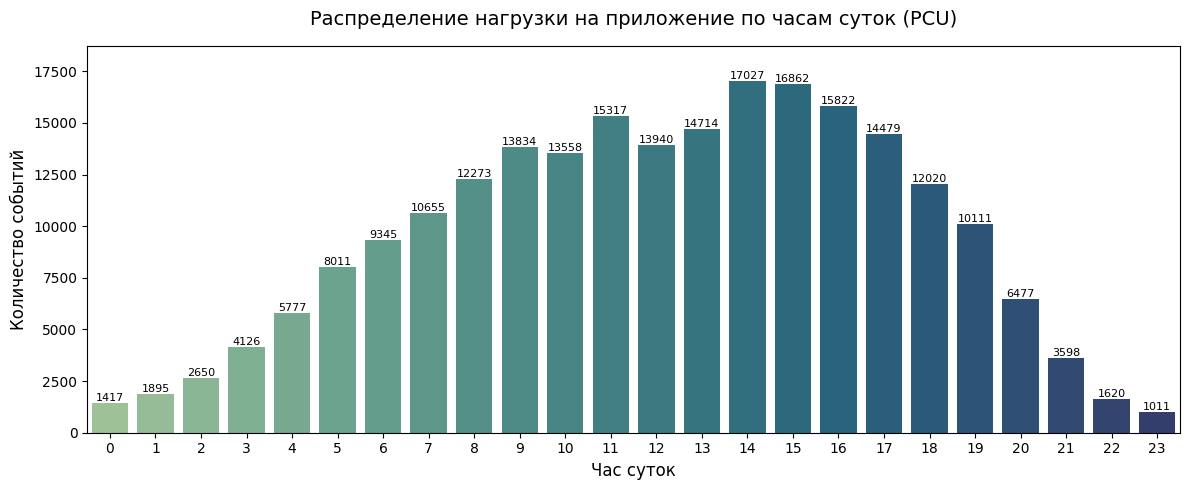

In [39]:
# визуализация нагрузки по часам
plt.figure(figsize=(12, 5))
plt.title('Распределение нагрузки на приложение по часам суток (PCU)', fontsize=14, pad=15)
ax = sns.barplot(x=pcu.index, y=pcu.values, palette='crest')
plt.xlabel('Час суток', fontsize=12)
plt.ylabel('Количество событий', fontsize=12)
plt.xticks(range(0, 24))

# подписи со значениями над каждым столбцом
for p in ax.patches:
    height = p.get_height()
    # Размещаем текст по центру столбца (get_x() + width/2) и чуть выше его верха (va='bottom')
    ax.text(p.get_x() + p.get_width() / 2., height, f'{int(height)}', 
            ha='center', va='bottom', fontsize=8, color='black')

# увеличиваем верхнюю границу оси Y на 10%, чтобы верхние цифры поместились на график
plt.ylim(0, max(pcu.values) * 1.1)
plt.tight_layout()
plt.show()

**Вывод:** Средняя нагрузка (ACU) составляет около 1434 уникальных пользователей в час. **Пиковая нагрузка (PCU) приходится на период с 14:00 до 16:00 (в часы обеденного перерыва),** где количество событий достигает 17 000+ в час. Эта **информация** критически важна **для технического отдела:** масштабирование серверов, выкатывание обновлений или **проведение технических работ** следует планировать на **ночные часы (с 01:00 до 05:00),** когда нагрузка падает до минимума. **Рекламные пуш-уведомления** бизнесу целесообразно **запускать** ровно перед пиковыми часами **(в 13:00 - 13:30).**

[к содержанию](#content) | [шаг 1](#1) | [шаг 2](#2) | [шаг 3](#3) | [шаг 4](#4) | [шаг 5](#5) | [шаг 6](#6) 

<a id=4></a>
## Шаг 4. Изучение воронки событий

<a id=4.1></a>
### 4.1. Посмотрите, какие события есть в логах, как часто они встречаются. Отсортируйте события по частоте.

In [40]:
# выводим данные, сгруппированные по типу событий
df_event = df.groupby('event_name').agg(total_events=('event_name','count')).reset_index().\
sort_values(by='total_events', ascending=False)
df_event['percent'] = df_event['total_events'] / df.shape[0] * 100
df_event

,event_name,total_events,percent
1,MainScreenAppear,108849,48.05
2,OffersScreenAppear,44419,19.61
0,CartScreenAppear,40137,17.72
3,PaymentScreenSuccessful,32133,14.18
4,Tutorial,1001,0.44


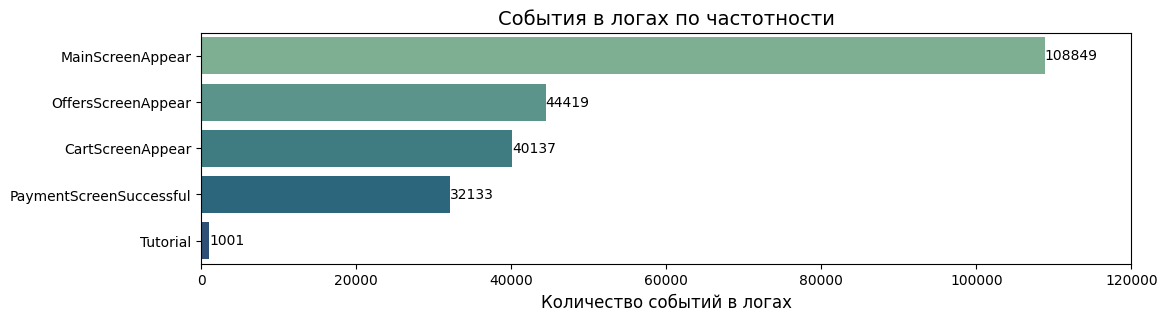

In [41]:
# визуализируем частотность событий в логах
plt.figure(figsize=(12,3))
plt.title('События в логах по частотности', size=14)
plots = sns.barplot(data=df_event, x='total_events', y='event_name', estimator=np.sum, palette='crest')

for p in plots.patches:
    width = p.get_width()
    plt.text(0.02 + p.get_width(), p.get_y()+0.5*p.get_height(), '{:1.0f}'.format(width), ha='left', va='center')

plt.ylabel('')
plt.xlabel('Количество событий в логах', size=12)
plt.xlim(0, 120000)
plt.show()

**Вывод:** наиболее часто встречающееся в логах событие - просмотр главной страницы сайта. Из общего количества записей о действиях пользователей на сайте, равного 226 539 строк, почти половина, а именно 48% или 108 849 строк зафиксировали просмотр главной страницы сайта. Реже всего встречаются записи о просмотре обучающего материала о взаимодействии с приложением - таких строк всего 0.44% или 1001.

<a id=4.2></a>
### 4.2. Посчитайте, сколько пользователей совершали каждое из этих событий

Отсортируйте события по числу пользователей. Посчитайте долю пользователей, которые хоть раз совершали событие.

In [42]:
# выводим данные, сгруппированные по пользователям
df_users = (df.groupby('event_name').agg({'device_id': 'nunique'}).reset_index().
          rename(columns={'device_id' : 'total_users'}).sort_values(by='total_users', ascending=False))
df_users['percent'] = df_users['total_users'] / df['device_id'].nunique() * 100
df_users

,event_name,total_users,percent
1,MainScreenAppear,6887,98.53
2,OffersScreenAppear,4318,61.77
0,CartScreenAppear,3518,50.33
3,PaymentScreenSuccessful,3334,47.70
4,Tutorial,836,11.96


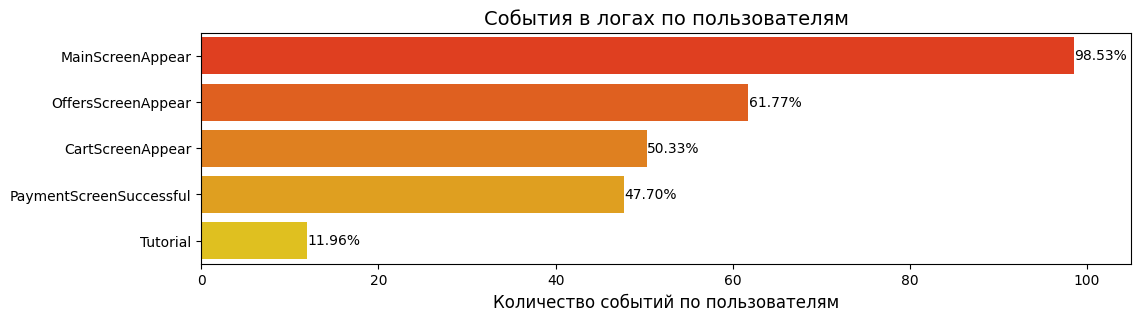

In [43]:
# визуализируем частотность событий в логах по пользователям
plt.figure(figsize=(12,3))
plt.title('События в логах по пользователям', size=14)
plots = sns.barplot(data=df_users, x='percent', y='event_name', estimator=np.sum, palette='autumn')

for p in plots.patches:
    width = p.get_width()
    plt.text(0.02 + p.get_width(), p.get_y()+0.5*p.get_height(), '{:1.2f}%'.format(width), ha='left', va='center')

plt.ylabel('')
plt.xlabel('Количество событий по пользователям', size=12)
plt.xlim(0, 105)
plt.show()

**Вывод:** нами были выполнены расчёты количества событий, которые совершили пользователи. 98% пользователей открыли главную страницу приложения, 61% - посмотрели каталог товаров, до просмотра карточки товара добрались почти 50% пользователей, 47% - успешно завершили оформление заказа и оплатили его. Почти 12% пользователей изучили обучающий материал о взаимодействии с приложением.

<a id=4.3></a>
### 4.3. Предположите, в каком порядке происходят события. Все ли они выстраиваются в последовательную цепочку? Их не нужно учитывать при расчёте воронки.

Исходя из расчётов и визуализаций, полученных на двух предыдущих этапах исследовательской части данного проекта, мы можем с уверенностью предположить, что последовательность событий взаимодействия с приложением выглядит следующим образом:
1. Просмотр главной страницы;
2. Просмотр каталога товаров;
3. Просмотр карточки товара;
4. Успешная оплата товара.

Событие `Tutorial`, во время которого пользователь знакомится с приложением в формате видеоинструкции или чтения информационного блока «Часто задаваемые вопросы», мы можем исключить из указанной последовательности.  

In [44]:
# исключаем из анализа событие просмотра обучающего материала взаимодействия с приложением
df = df[df['event_name'] != 'Tutorial']

<a id=4.4></a>
### 4.4. По воронке событий посчитайте, какая доля пользователей проходит на следующий шаг воронки (от числа пользователей на предыдущем). То есть для последовательности событий A → B → C посчитать отношение числа пользователей с событием B к количеству пользователей с событием A, а также отношение числа пользователей с событием C к количеству пользователей с событием B.

In [45]:
# обновим расчёты агрегированной таблицы событий по пользователям
df_users = (df.groupby('event_name').agg({'device_id': 'nunique'}).reset_index().
          rename(columns={'device_id' : 'total_users'}).sort_values(by='total_users', ascending=False))
df_users['percent'] = df_users['total_users'] / df['device_id'].nunique() * 100
df_users

,event_name,total_users,percent
1,MainScreenAppear,6887,98.58
2,OffersScreenAppear,4318,61.81
0,CartScreenAppear,3518,50.36
3,PaymentScreenSuccessful,3334,47.72


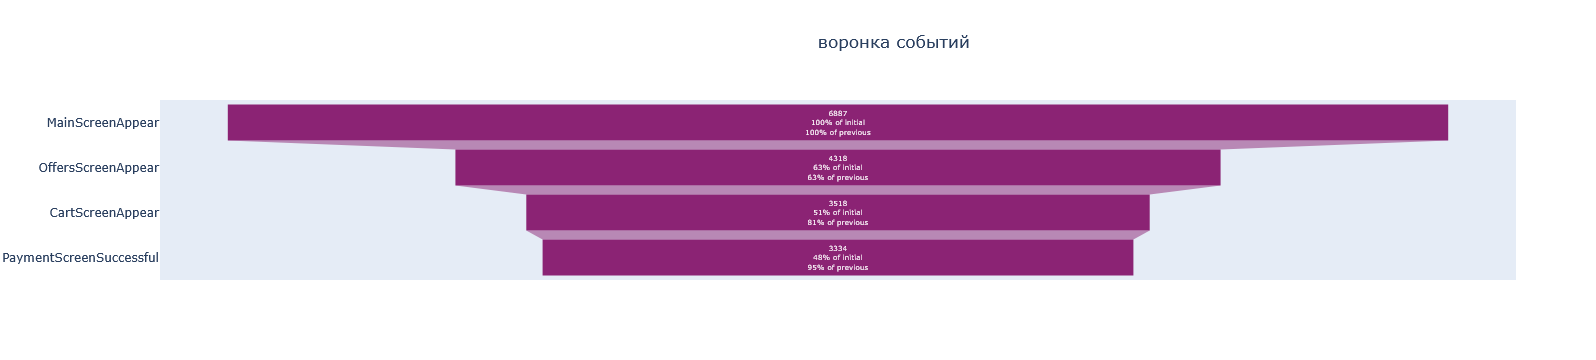

In [46]:
# полученные ранее расчёты визуализируем с помощью диаграммы воронки событий
fig = go.Figure(go.Funnel(y = df_users['event_name'], x = df_users['total_users'], opacity = 1, textposition = 'inside',
                          textinfo = 'value+percent previous+percent initial'))
fig.update_layout(title={'text': "воронка событий", 'xanchor': 'center', 'x':0.56, 'y':0.9}, colorway=['#8B2374'])
fig.show()

<a id=4.5></a>
### 4.5. На каком шаге теряете больше всего пользователей?

Информацию, представленную автоматическими расчётами на графике воронки событий, мы можем подкрепить самостоятельными расчётами. Для этого создадим сводную таблицу, в которой строки по каждому пользователю будут содержать сведения о времени совершения того или иного действия.

In [47]:
# расчёт присутствия и потерь пользователей по воронке событий
funnel_steps = df.pivot_table(index='device_id', columns='event_name', values='event_date', aggfunc='min')
funnel_steps = funnel_steps[['MainScreenAppear', 'OffersScreenAppear', 'CartScreenAppear', 'PaymentScreenSuccessful']]
funnel_steps.head()

event_name,MainScreenAppear,OffersScreenAppear,CartScreenAppear,PaymentScreenSuccessful
device_id,,,,
6888746892508752,2019-08-06 14:06:34,NaT,NaT,NaT
6909561520679493,2019-08-06 18:52:54,2019-08-06 18:53:04,2019-08-06 18:52:58,2019-08-06 18:52:58
6922444491712477,2019-08-04 14:19:33,2019-08-04 14:19:46,2019-08-04 14:19:40,2019-08-04 14:19:40
7435777799948366,2019-08-05 08:06:34,NaT,NaT,NaT
7702139951469979,2019-08-01 04:29:54,2019-08-01 04:29:56,2019-08-02 14:28:45,2019-08-02 14:28:45


In [48]:
# всего пользователей на момент захода в воронку событий
funnel_steps['MainScreenAppear'].count()

np.int64(6887)

**Примечание:** на этапе подготовки данных через `pivot_table` мы зафиксировали первое время совершения каждого события для каждого пользователя. Текущий расчёт конверсии через `.nunique()` учитывает сам факт наличия события в истории пользователя. В условиях продакшн-задачи для построения строгой временной воронки мы бы дополнительно отфильтровали датафрейм `funnel_steps`, оставив только тех пользователей, у которых соблюдена строгая хронология (например, `time_main` < `time_offers` < `time_cart` < `time_payment`).

> ##### **оставляем только тех, кто прошел шаги в правильном хронологическом порядке**
>strict_funnel = funnel_steps[
>    (funnel_steps['MainScreenAppear'] < funnel_steps['OffersScreenAppear']) &
>    (funnel_steps['OffersScreenAppear'] < funnel_steps['CartScreenAppear']) &
>    (funnel_steps['CartScreenAppear'] < funnel_steps['PaymentScreenSuccessful'])
>]
> ##### **расчёт по строгому хронологическому датафрейму**
>print('Шаг 1:', strict_funnel['MainScreenAppear'].count())
>print('Шаг 2:', strict_funnel['OffersScreenAppear'].count())

Однако для целей данного исследовательского проекта полагаем достаточным применение следующего кода:

In [49]:
# Шаг 1. Просмотр главной страницы, человек:
print('Шаг 1. Просмотр главной страницы, человек:', funnel_steps['MainScreenAppear'].nunique(), 
      'или', '{:.1%}'.format(funnel_steps['MainScreenAppear'].count() / funnel_steps['MainScreenAppear'].count()))
# Шаг 2. Просмотр каталога товаров, человек:
print('Шаг 2. Просмотр каталога товаров, человек:', funnel_steps['OffersScreenAppear'].nunique(), 
      'или', '{:.1%}'.format(funnel_steps['OffersScreenAppear'].count() / funnel_steps['MainScreenAppear'].count()))
# Шаг 3. Просмотр карточки товара, человек:
print('Шаг 3. Просмотр карточки товара, человек:', funnel_steps['CartScreenAppear'].nunique(), 
      'или', '{:.1%}'.format(funnel_steps['CartScreenAppear'].count() / funnel_steps['OffersScreenAppear'].count()))
# Шаг 4. Успешная оплата товара, человек:
print('Шаг 4. Успешная оплата товара, человек:', funnel_steps['PaymentScreenSuccessful'].nunique(), 
      'или', '{:.1%}'.format(funnel_steps['PaymentScreenSuccessful'].count() / funnel_steps['CartScreenAppear'].count()))

Шаг 1. Просмотр главной страницы, человек: 6796 или 100.0%
Шаг 2. Просмотр каталога товаров, человек: 4282 или 62.7%
Шаг 3. Просмотр карточки товара, человек: 3495 или 81.5%
Шаг 4. Успешная оплата товара, человек: 3316 или 94.8%


In [50]:
# расчёт потери доли покупателей, прошедших путь от начала воронки до Шага 2. Просмотр каталога товаров
100 - funnel_steps['OffersScreenAppear'].nunique() * 100 / funnel_steps['MainScreenAppear'].nunique()

36.99234844025898

**Вывод:** на основании полученных автоматическим и механическим способом расчётов, наибольшее количество пользователей теряется после первого шага, их количество составляет порядка 37%. 

<a id=4.6></a>
### 4.6. Какая доля пользователей доходит от первого события до оплаты?

In [51]:
# расчёт доли покупателей, прошедших путь от начала воронки до Шага 4. Успешная оплата товара
funnel_steps['PaymentScreenSuccessful'].nunique() * 100 / funnel_steps['MainScreenAppear'].nunique()

48.79340788699235

**Вывод:** порядка 48% первоначальных пользователей становятся покупателями и успешно оплачивают выбранный в приложении товар.

Таким образом, нами была изучена воронка событий взаимодействия пользователей с приложением в период с 1 по 7 августа 2019 года. Всего в логах мы наблюдаем 5 типов событий. Из них наиболее часто встречающееся - просмотр главной страницы сайта (98% пользователей), реже всего встречаются записи о просмотре обучающего материала о взаимодействии с приложением (12% пользователей). 61% - посмотрели каталог товаров, до просмотра карточки товара добрались почти 50% пользователей, 47% - успешно завершили оформление заказа и оплатили его.

На основании имеющихся данных, мы можем  предположить, что последовательность событий взаимодействия с приложением выглядит следующим образом: `Просмотр главной страницы` → `Просмотр каталога товаров` → `Просмотр карточки товара` → `Успешная оплата товара`. Событие `Tutorial`, во время которого пользователь знакомится с приложением в формате видеоинструкции или чтения информационного блока «Часто задаваемые вопросы», было исключено из указанной последовательности, поскольку оно носит справочно-информационный характер.

С помощью метода `go.Figure(go.Funnel)` библиотеки `Plotly` была построена диаграмма воронки событий с автоматическими расчётами процентного соотношения между исходным количеством пользователей и количеством, полученным на предыдущем шаге воронки. Автоматически полученные рассчёты на воронке событий мы подкроепили самостоятельными расчётами. В результате было установлено, что наибольшее количество пользователей теряется сразу после первого шага. Таким образом, 37% аудитории закрывает приложение сразу после просмотра главной страницы. Порядка 48% первоначальных пользователей становятся покупателями и успешно оплачивают выбранный в приложении товар.

Поведение пользователей даже на недельном отрезке является материалом для отдельного исследования. Полагаем возможным сформулировать только лишь некоторые предположения и рекомендации относительно текущего существования продуктового приложения и его возможного дальнейшего развития. На момент полученных данных мы можем точно констатировать факт успешности приложения-стартапа по продаже продуктов питания. 48% пользовательской аудитории, а это буквально каждый второй пользователь, становится покупателем. На предоставленном исследовательском материале мы видим незначительные потери аудитории на следующих шагах воронки событий: `OffersScreenAppear`, `CartScreenAppear`, `PaymentScreenSuccessful`.

Опасения вызывает провал показателя по количеству переходов пользователей с первого на второй шаг воронки событий, а именно: `MainScreenAppear` и `OffersScreenAppear`, равный -37%. Мы настоятельно рекомендуем изучить вопрос с функциональностью главной страницы не только группе дизайнеров, ответственной за макет страницы, но и команде технического сопровождения. Предположительно, либо не срабатывает скрипт перехода на страницу с каталогом товаров, либо ссылка визуально не понятна пользователям или макет страницы глобально не вызывает интереса потенциальных покупателей.
    
Для более глубокого понимания процессов взаимодействия пользователей с продуктовым приложением, на наш взгляд, необходимо рассчитать метрики DAU, WAU и Sticky factor. Именно этим бизнес-метрики оценивают пользовательскую активность и помогают понять владельцам бизнеса, сколько людей заинтересованы в их цифровом продукте.   
    
Среднее количество уникальных пользователей в сутки составляет 3675 человек, за неделю - 6278 человек, недельный фактор липучести составляет 58.5% процентов, что определённо является успехом. Высокий процент «липучести» означает, что люди часто пользуются этим приложением и с высокой вероятностью, они будуте рекомендовать его друзьям и знакомым, что в перспективе положительно повлияет на прирост активной аудитории. По этим метрикам мы можем утверждать, что приложение нашло свою аудиторию и закрывает её потребности.
    
Как часто пользователи обращаются к приложению? Метрику липучести хорошо дополняет медианное количество событий на пользователя. В нашем случае, это 20 единиц на человека. Половина пользователей приложения совершает именно 20 действий, в то время как ещё половина пользователей - почти 90 действий. В такой серьёзной разнице может скрываться техническая проблема работы приложения на разных платформах: для кого-то из пользователей комфортно взаимодействовать с материалом, и они сёрфят по страницам каталога и карточкам товара достаточно часто и это, в конечном итоге, приводит к покупкам. А половина пользователей завершает "контакт" 20-ю действиями. Этот момент предстоит рассмотреть и оптимизировать для улучшения KPI-показателей по длительности и частотности пребывания пользователей. Также стоит отметить, что фанатов-залипал у приложения очень мало: всего 76 человек часто обращаются к приложению в поиске продуктов питания.
    
В среднем онлайн за час могут присутствовать порядка 1500 пользователей, за день – 3675 человек, а за неделю приложение открыли порядка 6300 человек. 
    
Одномоментно за один час в приложении находятся до 17883 пользователей. Почти половину дня в приложении одновременно (за час) могут присутствовать от 11000 пользователей. В вечерние часы и ранним утром нагрузка минимальная – это идеальный временной интервал для обновлений и исправлений в работе платформы приложения. А вот новые рекламные акции стоит размещать в пиковые часы прибывания пользователей: с 14 до 16 часов включительно. Здесь максимальный охват аудитории составит от 16700 до 17883 человек.
    
И если мы определились со временем суток для привлечения аудитории, то в контексте недели самым ярким днём пользовательской активности является вторник, ему немногим уступает понедельник. Вообще, частотность посещения приложения пользователями довольно ровная и стабильная в разрезе недели, небольшой спад мы отмечаем в понедельник.
    
Это очень достойные показатели результативности. В целях улучшения вышеназванных метрик, мы мождем предложить рассмотреть возможность внедрения опции доставки продуктов питания, это улучшит сразу целый ряд метрик приложения. Кроме того, учитывая максимальные часы нагрузки, предлагаем рассмотреть вопрос сотрудничества с сетями фаст-фуда, кафетериев, реализующих опцию доставки: так, чтобы захватить 1) предобеденный интервал нагрузки на приложение, а также 2) круглосуточную доставку и нарастить аудиторию. Любителей поесть в позднее вечернее время или ночью, конечно, меньше, чем обычных среднестатистических пользователей, но во-превых, эта аудитория чаще всего соотносится с социально значимыми профессиями (работа медицинского персонала, технических служб, служб безопасности, в которых графики труда охватывают ночной период суток), а во-вторых, прирост аудитории приложения может привести и к приросту прибыли, что и является самоцелью.

[к содержанию](#content) | [шаг 1](#1) | [шаг 2](#2) | [шаг 3](#3) | [шаг 4](#4) | [шаг 5](#5) | [шаг 6](#6) 

<a id=5></a>
## Шаг 5. Изучение результатов эксперимента

<a id=5.1></a>
### 5.1. Сколько пользователей в каждой группе?

In [52]:
# актуализируем данные по количественному соотношению пользователей в разрезе групп
dstart = df.groupby('exp_id').agg(users_per_group= ('device_id','nunique'))
dstart

,users_per_group
exp_id,
246,2302
247,2335
248,2349


**Вывод:** на предыдущем этапе исследовательского анализа данных нами был исключено событие `Tutorial`, поскольку оно самодостаточно и не включено в логику воронки событий. На текущий момент изучения результатов эксперимента мы имеем датафрейм `df` размером 225 538 строк x 5 признаков. В этом датафрейме представлены все три экспериментальные группы, количество пользователей в каждой из них имеет несущественные отличия. Самая многочисленная - группа 248, в ней насчитывается 2349 человек. Немногим меньше в группе 247 - 2335 человек, или 99.4% от самой многочисленной группы 248. В группе 246 меньше всего представителей, их 2302 или 98% от от самой многочисленной группы 248. Таким образом, численность пользователей по группам распределена равномерно.

<a id=5.2></a>
### 5.2. Есть 2 контрольные группы для А/А-эксперимента, чтобы проверить корректность всех механизмов и расчётов. Проверьте, находят ли статистические критерии разницу между выборками 246 и 247

In [53]:
# создаём сводную таблицу с данными по каждой тестовой группе
exp = df.pivot_table(index='exp_id', values='device_id', columns='event_name', aggfunc='nunique')
exp = exp.merge(dstart['users_per_group'], on='exp_id')
# пересобираем порядок признаков в соответствии с воронкой событий
exp = exp[['users_per_group', 'MainScreenAppear', 'OffersScreenAppear', 'CartScreenAppear', 'PaymentScreenSuccessful']]
exp

,users_per_group,MainScreenAppear,OffersScreenAppear,CartScreenAppear,PaymentScreenSuccessful
exp_id,,,,,
246,2302,2271,1464,1207,1145
247,2335,2302,1419,1161,1085
248,2349,2314,1435,1150,1104


In [54]:
df

,exp_id,device_id,event_name,event_date,date,event_week,hour
2827,246,3737462046622621720,MainScreenAppear,2019-08-01 00:08:00,2019-08-01,31,0
2828,246,3737462046622621720,MainScreenAppear,2019-08-01 00:08:55,2019-08-01,31,0
2829,246,3737462046622621720,OffersScreenAppear,2019-08-01 00:08:58,2019-08-01,31,0
2830,247,1433840883824088890,MainScreenAppear,2019-08-01 00:08:59,2019-08-01,31,0
2831,247,4899590676214355127,MainScreenAppear,2019-08-01 00:10:15,2019-08-01,31,0
...,...,...,...,...,...,...,...
243708,247,4599628364049201812,MainScreenAppear,2019-08-07 21:12:25,2019-08-07,32,21
243709,246,5849806612437486590,MainScreenAppear,2019-08-07 21:13:59,2019-08-07,32,21
243710,246,5746969938801999050,MainScreenAppear,2019-08-07 21:14:43,2019-08-07,32,21
243711,246,5746969938801999050,MainScreenAppear,2019-08-07 21:14:58,2019-08-07,32,21


Итак, мы получили сводную таблицу с данными о количестве пользователей и количестве каждого типа событий в разрезе групп. 

In [55]:
# создаём таблицу для визуализации воронки событий в разрезе тестовых групп
funnel_exp = (df.groupby(['event_name', 'exp_id']).agg({'device_id': 'nunique'}).reset_index().\
rename(columns={'device_id' : 'total_users'}).sort_values(by=['exp_id', 'total_users'], ascending=False))

In [56]:
funnel_exp

,event_name,exp_id,total_users
5,MainScreenAppear,248,2314
8,OffersScreenAppear,248,1435
2,CartScreenAppear,248,1150
11,PaymentScreenSuccessful,248,1104
4,MainScreenAppear,247,2302
7,OffersScreenAppear,247,1419
1,CartScreenAppear,247,1161
10,PaymentScreenSuccessful,247,1085
3,MainScreenAppear,246,2271
6,OffersScreenAppear,246,1464


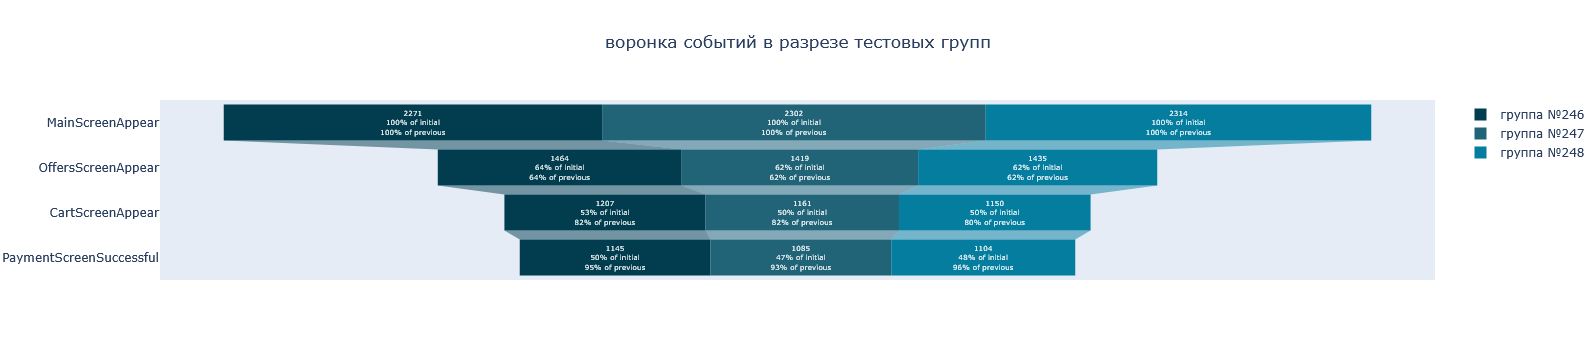

In [57]:
# воронка событий в разрезе тестовых групп
fig = go.Figure()
fig.add_trace(go.Funnel(name = 'группа №246',
                        y = funnel_exp.query('exp_id == 246')['event_name'],
                        x = funnel_exp.query('exp_id == 246')['total_users'],
                        textposition = 'inside',
                        textinfo = 'value+percent previous+percent initial'))

fig.add_trace(go.Funnel(name = 'группа №247',
                        y = funnel_exp.query('exp_id == 247')['event_name'],
                        x = funnel_exp.query('exp_id == 247')['total_users'],
                        textposition = 'inside',
                        textinfo = 'value+percent previous+percent initial'))

fig.add_trace(go.Funnel(name = 'группа №248',
                        y = funnel_exp.query('exp_id == 248')['event_name'],
                        x = funnel_exp.query('exp_id == 248')['total_users'],
                        textposition = 'inside',
                        textinfo = 'value+percent previous+percent initial'))
                        
fig.update_layout(title={'text': 'воронка событий в разрезе тестовых групп', 
                         'xanchor': 'center', 'x':0.5, 'y':0.9}, 
                  colorway=['#013D4F', '#216477', '#057D9F'])
fig.show()

Визуальное знакомство с полученными данными позволяет нам сделать первичное предположение о том, что нововведение в виде смены шрифтов во всём приложении не возымело никакого воздействия на пользователей: показатели всех трёх групп едва ли различаются.

В нашем распоряжении не только агрегированные данные и дополнительные построения диаграммы воронки событий в разрезе каждой тестовой группы, но и статистические методы. Для проверки равенства средних значений генеральной совокупности, когда дисперсии известны и размер выборки велик, обычно применяется `z-критерий Фишера`, основанный на нормальном распределении данных. Нам предстоит провести А/А-тестирование, чтобы проверить корректность всех механизмов и расчётов. Суть такого тестирования заключается в том, что опыт группы 246 должен быть идентичен опыту группы 247. Следовательно, в случае успешного А/А-теста, не будет выявлена группа-победитель, превосходящая побеждённую группу участников по какому-либо параметру. 

Напишем универсальную функцию, позволяющую проверить статистические критерии разницы между долями по шагам воронки собыйти контрольных групп. На вход передадим номера двух групп для сравнения, наименование события(-ий) и уровень статистической значимости. 

В случае успешного завершения А/А-теста мы сможем применить эту функцию в дальнейшей работе. 

Сформулируем гипотезы:
$$
\begin{equation*}
 \begin{cases}
   \text{H}_0 \text{ : доля пользователей группы 246 на текущем шаге воронки событий} = \text{доля пользователей группы 247 на текущем шаге воронки событий}
   \\
   \text{H}_1 \text{ : доля пользователей группы 246 на текущем шаге воронки событий} \neq \text{доля пользователей группы 247 на текущем шаге воронки событий}
   \\
 \end{cases}
\end{equation*}
$$

Установим пороговое значение: $ \alpha = 0.001$

In [58]:
# создание универсальной функции для расчёта статистически значимой разницы между долями двух групп

def return_z_test(group1, group2, event, alpha):
    '''
    Функция реализует классический Z-критерий для сравнения двух долей (Two-Proportion Z-Test) 
    с использованием объединённой доли. Была написана вручную для понимания математического аппарата
    и гибкой интеграции поправки Бонферрони.
    
    Примечание! В промышленных задачах для этой же цели удобно использовать готовую функцию 
    proportions_ztest из библиотеки statsmodels.stats.proportion
    '''

    res = []
    # подсчёт количества пользователей и количества событий в каждой группе
    p1_ev = exp.loc[group1, event]
    p2_ev = exp.loc[group2, event] 
    p1_us = exp.loc[group1, 'users_per_group'] 
    p2_us = exp.loc[group2, 'users_per_group'] 
    
    # доля пользователей, совершивших событие в разрезе групп:
    p1 = p1_ev / p1_us 
    p2 = p2_ev / p2_us
    
    # разница долей в датафреймах групп
    difference = p1 - p2

    # пропорция успехов в комбинированном датафрейме (с учётом объединённых долей)
    p_combined = (p1_ev + p2_ev) / (p1_us + p2_us) 
    
    # считаем статистику в стандартных отклонениях стандартного нормального распределения
    z_value = difference / mth.sqrt(p_combined *(1-p_combined) * (1 / p1_us + 1 / p2_us))
    
    # задаём стандартное нормальное распределение (среднее 0, стандартное отклонение 1)
    distr = st.norm(0, 1) 
    
    # поскольку это двусторонний тест, удваиваем результат
    p_value = (1 - distr.cdf(abs(z_value))) * 2
        
    print('Между выборками групп №{} и №{} по событию «{}» при установленном пороговом значении 𝛼={} статистический уровень значимости p-value составляет {:.2f}.'.format(group1, group2, event, alpha, p_value ))
    
    # поправка Бонферрони
    bnf_alpha = alpha / 16
    
    # определение правила принятия решения      
    if (p_value < bnf_alpha):
        print('Отвергаем нулевую гипотезу: между долями есть значимая разница.')
    else:
        print('Не получилось отвергнуть нулевую гипотезу, нет оснований считать доли разными.')

<a id=5.3></a>
### 5.3. Выберите самое популярное событие

In [59]:
# выводим датафрейм `exp` с данными по шагам воронки событий
exp

,users_per_group,MainScreenAppear,OffersScreenAppear,CartScreenAppear,PaymentScreenSuccessful
exp_id,,,,,
246,2302,2271,1464,1207,1145
247,2335,2302,1419,1161,1085
248,2349,2314,1435,1150,1104


**Вывод:** на основании расчётов и имеющихся данных мы можем утверждать, что самое популярное событие у пользователей - просмотр главной страницы приложения `MainScreenAppear`. Это характерно для представителей всех трёх групп пользователей.

<a id=5.4></a>
### 5.4. Посчитайте число пользователей, совершивших это событие в каждой из контрольных групп

In [60]:
# расчёт количества пользователей, совершихвших самое популярное событие
exp_main_screen = df.groupby(['event_name', 'exp_id']).agg({'device_id': 'nunique'}).\
query('event_name == "MainScreenAppear"').\
rename(columns={'device_id' : 'total_users'}).sort_values(by=['total_users'], ascending=False).reset_index()
exp_main_screen[['exp_id','total_users']]

,exp_id,total_users
0,248,2314
1,247,2302
2,246,2271


**Вывод:** количество пользователей, просматривавших главную страницу приложения, во всех трёх группах распределено равномерно и находится в диапазоне от 2271 человек до 2314 человек. Самое большое количество людей, открывших главную страницу приложения, зафиксировано в группе №248 и составляет 2314 человек, меньше всего - в группе №246, таких пользователей 2271 человек.

<a id=5.5></a>
### 5.5. Посчитайте долю пользователей, совершивших это событие

In [61]:
# расчёт доли пользователей, открывших главную страницу приложения от общего количества пользователей
exp_main_screen['percent'] = exp_main_screen['total_users'] / exp_main_screen['total_users'].sum() * 100
exp_main_screen[['exp_id','total_users','percent']]

,exp_id,total_users,percent
0,248,2314,33.60
1,247,2302,33.43
2,246,2271,32.98


**Вывод:** из общего количества пользователей доля пользователей, просматривавших главную страницу приложения, распределилась равномерно между всем тремя тестовыми группами и составила диапазон значений от 32.98% до 33.6%.

<a id=5.6></a>
### 5.6. Проверьте, будет ли отличие между группами статистически достоверным

Сформулируем универсальный макет гипотез:
$$
\begin{equation*}
 \begin{cases}
   \text{H}_0 \text{ : доля пользователей группы 246 на 1 шаге воронки событий} = \text{доля пользователей группы 247 на 1 шаге воронки событий}
   \\
   \text{H}_1 \text{ : доля пользователей группы 246 на 1 шаге воронки событий} \neq \text{доля пользователей группы 247 на 1 шаге воронки событий}
   \\
 \end{cases}
\end{equation*}
$$

Установим пороговое значение: $ \alpha = 0.001$

In [62]:
# передаём самое популярное событие в виде списка, который будет проверен статистическим тестом в разрезе групп
event_name = ['MainScreenAppear'] 

for event in event_name:
    
    return_z_test(246, 247, event, 0.001)
    print()

Между выборками групп №246 и №247 по событию «MainScreenAppear» при установленном пороговом значении 𝛼=0.001 статистический уровень значимости p-value составляет 0.85.
Не получилось отвергнуть нулевую гипотезу, нет оснований считать доли разными.



**Вывод:** в результате z-теста не получилось отвергнуть нулевую гипотезу о равенстве долей пользователей обеих контрольных групп, просматривавших главную страницу приложения.

<a id=5.7></a>
### 5.7. Проделайте то же самое для всех других событий. Можно ли сказать, что разбиение на группы работает корректно?

Сформулируем универсальный макет гипотез для проверки статистического уровня значимости в отношении всех шагов воронки событий в разрезе контрольных групп №246 и №247:

$$
\begin{equation*}
 \begin{cases}
   \text{H}_0 \text{ : доля пользователей группы 246 на текущем шаге воронки событий} = \text{доля пользователей группы 247 на текущем шаге воронки событий}
   \\
   \text{H}_1 \text{ : доля пользователей группы 246 на текущем шаге воронки событий} \neq \text{доля пользователей группы 247 на текущем шаге воронки событий}
   \\
 \end{cases}
\end{equation*}
$$

Установим пороговое значение: $ \alpha = 0.001$

In [63]:
# дополним список событий, который будет проверен статистическими тестами в разрезе групп
event_name = ['MainScreenAppear', 'OffersScreenAppear', 'CartScreenAppear', 'PaymentScreenSuccessful'] 

for event in event_name:
    return_z_test(246, 247, event, 0.001)
    print()

Между выборками групп №246 и №247 по событию «MainScreenAppear» при установленном пороговом значении 𝛼=0.001 статистический уровень значимости p-value составляет 0.85.
Не получилось отвергнуть нулевую гипотезу, нет оснований считать доли разными.

Между выборками групп №246 и №247 по событию «OffersScreenAppear» при установленном пороговом значении 𝛼=0.001 статистический уровень значимости p-value составляет 0.05.
Не получилось отвергнуть нулевую гипотезу, нет оснований считать доли разными.

Между выборками групп №246 и №247 по событию «CartScreenAppear» при установленном пороговом значении 𝛼=0.001 статистический уровень значимости p-value составляет 0.06.
Не получилось отвергнуть нулевую гипотезу, нет оснований считать доли разными.

Между выборками групп №246 и №247 по событию «PaymentScreenSuccessful» при установленном пороговом значении 𝛼=0.001 статистический уровень значимости p-value составляет 0.03.
Не получилось отвергнуть нулевую гипотезу, нет оснований считать доли разными.


**Вывод:** по итогам серии статистических тестов у нас нет оснований считать доли по всем типам событий в обеих контрольных группах разными. В завершении А/А-теста мы не можем установить в качестве победителя ни одну из контрольных групп. Полагаем, что деление траффика по группам работает корректно.

На основании вышеизложенного, мы фиксируем успешное завершение А/А-теста, отсутствие группы-победителя и можем перейти к изучению результатов A/B-теста.

<a id=5.8></a>
### 5.8. Аналогично поступите с группой с изменённым шрифтом. Сравните результаты с каждой из контрольных групп в отдельности по каждому событию

Сформулируем универсальный макет гипотез для проверки статистического уровня значимости в отношении всех шагов воронки событий в разрезе контрольной группы №246 и тестовой группы №248:

$$
\begin{equation*}
 \begin{cases}
   \text{H}_0 \text{ : доля пользователей группы 246 на текущем шаге воронки событий} = \text{доля пользователей группы 248 на текущем шаге воронки событий}
   \\
   \text{H}_1 \text{ : доля пользователей группы 246 на текущем шаге воронки событий} \neq \text{доля пользователей группы 248 на текущем шаге воронки событий}
   \\
 \end{cases}
\end{equation*}
$$

Установим пороговое значение: $ \alpha = 0.001$

In [64]:
# список событий, который будет проверен статистическими тестами в разрезе групп
event_name = ['MainScreenAppear', 'OffersScreenAppear', 'CartScreenAppear', 'PaymentScreenSuccessful'] 

for event in event_name:
    return_z_test(246, 248, event, 0.001)
    print()

Между выборками групп №246 и №248 по событию «MainScreenAppear» при установленном пороговом значении 𝛼=0.001 статистический уровень значимости p-value составляет 0.68.
Не получилось отвергнуть нулевую гипотезу, нет оснований считать доли разными.

Между выборками групп №246 и №248 по событию «OffersScreenAppear» при установленном пороговом значении 𝛼=0.001 статистический уровень значимости p-value составляет 0.08.
Не получилось отвергнуть нулевую гипотезу, нет оснований считать доли разными.

Между выборками групп №246 и №248 по событию «CartScreenAppear» при установленном пороговом значении 𝛼=0.001 статистический уровень значимости p-value составляет 0.02.
Не получилось отвергнуть нулевую гипотезу, нет оснований считать доли разными.

Между выборками групп №246 и №248 по событию «PaymentScreenSuccessful» при установленном пороговом значении 𝛼=0.001 статистический уровень значимости p-value составляет 0.06.
Не получилось отвергнуть нулевую гипотезу, нет оснований считать доли разными.


Сформулируем универсальный макет гипотез для проверки статистического уровня значимости в отношении всех шагов воронки событий в разрезе контрольной группы №247 и тестовой группы №248:
$$
\begin{equation*}
 \begin{cases}
   \text{H}_0 \text{ : доля пользователей группы 247 на текущем шаге воронки событий} = \text{доля пользователей группы 248 на текущем шаге воронки событий}
   \\
   \text{H}_1 \text{ : доля пользователей группы 247 на текущем шаге воронки событий} \neq \text{доля пользователей группы 248 на текущем шаге воронки событий}
   \\
 \end{cases}
\end{equation*}
$$

Установим пороговое значение: $ \alpha = 0.001$

In [65]:
# список событий, который будет проверен статистическими тестами в разрезе групп
event_name = ['MainScreenAppear', 'OffersScreenAppear', 'CartScreenAppear', 'PaymentScreenSuccessful'] 

for event in event_name:
    return_z_test(247, 248, event, 0.001)
    print()

Между выборками групп №247 и №248 по событию «MainScreenAppear» при установленном пороговом значении 𝛼=0.001 статистический уровень значимости p-value составляет 0.83.
Не получилось отвергнуть нулевую гипотезу, нет оснований считать доли разными.

Между выборками групп №247 и №248 по событию «OffersScreenAppear» при установленном пороговом значении 𝛼=0.001 статистический уровень значимости p-value составляет 0.82.
Не получилось отвергнуть нулевую гипотезу, нет оснований считать доли разными.

Между выборками групп №247 и №248 по событию «CartScreenAppear» при установленном пороговом значении 𝛼=0.001 статистический уровень значимости p-value составляет 0.60.
Не получилось отвергнуть нулевую гипотезу, нет оснований считать доли разными.

Между выборками групп №247 и №248 по событию «PaymentScreenSuccessful» при установленном пороговом значении 𝛼=0.001 статистический уровень значимости p-value составляет 0.72.
Не получилось отвергнуть нулевую гипотезу, нет оснований считать доли разными.


**Вывод:** на основании расчётов установлено, что статистические критерии при установленном пороговом альфа-уровне 0.001 не обнаруживают разницу между выборками контрольной группы №246 и тестовой группы №248, аналогичным образом выглядят результаты сравнительного анализа между контрольной группой №247 и тестовой группой №248.

<a id=5.9></a>
### 5.9. Сравните результаты с объединённой контрольной группой. Какие выводы из эксперимента можно сделать?

In [66]:
# создание объединённой контрольной группы № 249 из групп №246 и №247
exp.loc[249] = exp[['users_per_group', 'MainScreenAppear',\
               'OffersScreenAppear','CartScreenAppear','PaymentScreenSuccessful']][:2].sum(axis=0)
exp

,users_per_group,MainScreenAppear,OffersScreenAppear,CartScreenAppear,PaymentScreenSuccessful
exp_id,,,,,
246,2302,2271,1464,1207,1145
247,2335,2302,1419,1161,1085
248,2349,2314,1435,1150,1104
249,4637,4573,2883,2368,2230


Сформулируем универсальный макет гипотез для проверки статистического уровня значимости в отношении всех шагов воронки событий в разрезе объединённой контрольной группы №249 и тестовой группы №248:

$$
\begin{equation*}
 \begin{cases}
   \text{H}_0 \text{ : доля пользователей группы 249 на текущем шаге воронки событий} = \text{доля пользователей группы 248 на текущем шаге воронки событий}
   \\
   \text{H}_1 \text{ : доля пользователей группы 249 на текущем шаге воронки событий} \neq \text{доля пользователей группы 248 на текущем шаге воронки событий}
   \\
 \end{cases}
\end{equation*}
$$

Установим пороговое значение: $ \alpha = 0.001$

In [67]:
# список событий, который будет проверен статистическими тестами в разрезе групп
event_name = ['MainScreenAppear', 'OffersScreenAppear', 'CartScreenAppear', 'PaymentScreenSuccessful'] 

for event in event_name:
    return_z_test(249, 248, event, 0.001)
    print()

Между выборками групп №249 и №248 по событию «MainScreenAppear» при установленном пороговом значении 𝛼=0.001 статистический уровень значимости p-value составляет 0.71.
Не получилось отвергнуть нулевую гипотезу, нет оснований считать доли разными.

Между выборками групп №249 и №248 по событию «OffersScreenAppear» при установленном пороговом значении 𝛼=0.001 статистический уровень значимости p-value составляет 0.38.
Не получилось отвергнуть нулевую гипотезу, нет оснований считать доли разными.

Между выборками групп №249 и №248 по событию «CartScreenAppear» при установленном пороговом значении 𝛼=0.001 статистический уровень значимости p-value составляет 0.10.
Не получилось отвергнуть нулевую гипотезу, нет оснований считать доли разными.

Между выборками групп №249 и №248 по событию «PaymentScreenSuccessful» при установленном пороговом значении 𝛼=0.001 статистический уровень значимости p-value составляет 0.39.
Не получилось отвергнуть нулевую гипотезу, нет оснований считать доли разными.


**Выводы:** результаты данных статистических тестов, полученных при сравнении долей пользователей в объединённой контрольной группе №249 и тестовой группе №248, подкрепляют ранее полученные результаты: при установленном пороговом альфа-уровне в 0.001 у нас нет оснований считать доли разными на всех шагах воронки событий, характерных для исследуемого приложения.

<a id=5.10></a>
### 5.10. Какой уровень значимости вы выбрали при проверке статистических гипотез выше?

<b>Уровень значимости статистического теста</b> — это допустимая для данной задачи вероятность ошибки первого рода (ложноположительного решения или False Positive), то есть вероятность отклонить нулевую гипотезу, когда на самом деле она верна. Или это такое достаточно малое значение вероятности события, при котором событие уже можно считать неслучайным. Обычно уровень значимости обычно обозначают греческой буквой 𝛼 (альфа). Из-за такого обозначения его иногда называют альфа-уровнем.<a href='http://www.machinelearning.ru/wiki/index.php?title=%D0%A3%D1%80%D0%BE%D0%B2%D0%B5%D0%BD%D1%8C_%D0%B7%D0%BD%D0%B0%D1%87%D0%B8%D0%BC%D0%BE%D1%81%D1%82%D0%B8#.D0.92.D1.8B.D1.87.D0.B8.D1.81.D0.BB.D0.B5.D0.BD.D0.B8.D0.B5_ROC-.D0.BA.D1.80.D0.B8.D0.B2.D0.BE.D0.B9'>[1]</a>

Ошибка I рода описывается следующей математической формулой:

<center>$ \alpha = \mathbb{P} \left\{ T\in\Omega_\alpha | H_0 \right\}$</center>

Стандартными уровнями значимости являются 0.1; 0.05; 0.01 и 0.001. Исторически принято считать низшим уровнем статистической значимости 5%-ый уровень (р<0,05): достаточным - 1%-ый уровень (р<0,01) и высшим 0,1%-ый уровень (р<0,001). Когда мы указываем, что различия достоверны на 5%-ом уровне значимости, или при р<0,05, то мы имеем виду, что вероятность того, что они всё-таки недостоверны, составляет 0,05. Когда мы указываем, что различия достоверны на 1%-ом уровне значимости, или при р<0,01, то мы имеем в виду, что вероятность того, что они все-таки недостоверны, составляет 0,01.

Условно их можно выбирать так: если объём выборки небольшой до 100 единиц, то можно вполне отвергнуть нулевую гипотезу при уровне значимости 0.05 или даже 0.1. При объёме выборки, измеряемой сотнями – от 100 до 1000, следует понизить уровень значимости хотя бы до 0.01. <b>А при больших выборках, измеряемых тысячами наблюдений, уверенно отвергать нулевую гипотезу можно только при значимости меньшей 0.001.</b></b> <a href='https://www.statmethods.ru/stati/vybor-urovnya-znachimosti-pri-proverke-statisticheskikh-gipotez/'>[2]</a>

В нашем исследовании выборки на каждом шаге воронки событий насчитывают от 1085 до 4637 событий, следовательно, нами ранее был установлено пороговое значение 𝛼=0.001.

<a id=5.11></a>
### 5.11. Посчитайте, сколько проверок статистических гипотез вы сделали. При уровне значимости 0.1 каждый десятый раз можно получать ложный результат. Какой уровень значимости стоит применить?

В ходе исследования нами был выполнен А/А-тест, включающий 4 проверки соотношения долей в контрольных группах №246 и №247. В ходе А/В-теста были выполнены 4 проверки соотношения долей шагов воронки событий в группах №246 и №248, также 4 аналогичные проверки в группах №247 и №248 и 4 аналогичные проверки в объединённой контрольной группе №249, где представлены суммированные значения групп №246 и №247 и группы с изменёнными шрифтами приложения №248. Следовательно, нами были выполнены 4 проверки гипотез отдельного А/А-теста, и 12 проверок гипотез А/В-тестов, <b>итого: выполнено 16 проверок статистических гипотез.</b>

При множественной проверке гипотез возрастает <b>групповая вероятность совершить ошибку I рода</b> (т.е. хотя бы 1 раз из всех проверяемых гипотез) `FWER`. Для снижения этой вероятности применяется несколько различных подходов, нами была применена достаточно грубая поправка Бонферрони к требуемым уровням значимости. Смысл поправки заключается в том, что уровни значимости в каждом из `m` сравнений в `m` раз меньше, чем уровень значимости, требуемый при единственном сравнении. Проще говоря, уровень значимости `ɑ` мы разделили на число гипотез, то есть на 16.

Данная поправка на 16 тестируемых гипотез является консервативным решением, которое в нашем конкретном случае оправдано, поскольку: 1) исследуемая выборка - многочисленная, 2) нами установлен высший альфа-порог, при котором различия достоверны на 0,1% процентном уровне (р<0,001). 

Предалаемый к рассмотрению уровень статистической значимости 0.1 указывает на 10%-ю вероятность <b>совершения ошибки первого рода,</b> то есть ошибки отклонения нулевой гипотезы, в то время как она верна. Вероятность такой ошибки обычно обозначается как α. В сущности, мы должны были бы указывать в скобках не р≤0,05 или р≤0,01, а α≤0,05 или α≤0,01. В некоторых руководствах так и делается (Рунион Р. Справочник по непараметрической статистике. Современный подход. Пер. с английского Е.З. Демиденко. Предисловие Ю.Н.Тюрин. Москва, "Финансы и статистика", 1982; Захаров В.П. Применение математических методов в социально-психологических исследованиях: Учеб. пособие. Ленинград: ЛГУ, 1985). 

Поскольку наши суждения на основе результатов проверки гипотез всегда имеют вероятностный характер, то вне зависимости от принятого нами решения, всегда существует ошибка принятия этого решения. Рассмотрим все возможные ошибки при принятии решений:

*Таблица. Матрица ошибок*

|                | $$\text{Принять H}_0$$             | $$\text{Отвергнуть H}_0$$          |
|----------------|:-----------------------------------|:-----------------------------------|
| $$\text{H}_0$$ |Верное решение с вероятностью $ 1 – \alpha $ <br><b>True Positive| Ошибочное решение с вероятностью $\beta$<br><b>False Positive. <font color='red'>Ошибка II рода|
| $$\text{H}_1$$ | Ошибочное решение с вероятностью $\alpha$<br><b>False Negative. <font color='red'>Ошибка I рода | Верное решение с вероятностью $ 1 – \beta $<br><b>True Negative|

Расшифровка полученных значений:

| № п/п | Название (Eng)   | Название (Rus) | Значение признака                                 |
|-------|:-----------------|:---------------|:--------------------------------------------------|
|1.|`True Positive`  |Истинно положительный|Нулевая гипотеза принята верно с вероятностью с вероятностью 1-𝛼|
|2.|`False Positive` | Ложно положительный  |Ошибочное решение с вероятностью β. Это ошибка II рода, ложное обнаружение, т.к. при отсутствии события ошибочно выносится решение о его присутствии (ложно положительные случаи).|
|3.|`False Negative` |Ложно отрицательный  |Нулевая гипотеза неверно отвергнута.  Ошибочное решение с вероятностью 𝛼. Это ошибка I рода, так называемый «ложный пропуск» — когда интересующее нас событие ошибочно не обнаруживается.|
|4.|`True Negative`  | Истинно отрицательный|Верное решение с вероятностью 1-β|

Для оценки возможности совершения такой ошибки используют вероятность, обозначаемую α и называемую уровнем значимости критерия. Также возможна и ошибка второго рода $\beta$  – когда мы принимаем неверную нулевую гипотезу. 

Ошибка II рода описывается следующей математической формулой:
    
<center>$\beta(H_1) = \mathbb{P} \left\{ T\notin\Omega_\alpha | H_1 \right\}$</center>
    
На практике может использоваться величина $ \gamma = 1 – \beta $ или <b>мощность критерия</b> – вероятность не совершить ошибку второго рода или принять неверную гипотезу. Уровень $\beta$-риска тесно связан с 1) величиной различий между выборками (т.н. "величиной эффекта"), 2) числом наблюдений и 3) разбросом данных. Наиболее важным является число наблюдений: чем больше размер выборок, тем выше мощность теста. При "достаточно" больших выборках даже небольшие различия окажутся статистически значимыми. Проверка мощности - это важный критерий после проведения тестов статистической значимости. Эксперимент с низкой мощностью будет страдать от высокой частоты ложных отрицательных результатов (ошибок II рода). 
    
В полученных нами расчётах p-value имеет значения, близкие к 1, следовательно, тем больше у нас оснований не отвергать нулевую гипотезу.Таким образом, выбор критического уровня $\alpha$ имеет ключевое значение.
    
При заданном объёме выборки вероятность совершения ошибки I рода можно уменьшить, снижая уровень значимости $\alpha$. Однако при этом увеличивается вероятность ошибки II рода $\beta$, т.е. снижается мощность критерия. Выбор уровня значимости требует компромисса между заданной значимостью и мощностью. Увеличивая уровень значимости, мы увеличиваем шансы отвергнуть нулевую гипотезу, что является нашей конечной целью, а с другой стороны мы также увеличиваем и вероятность ошибки I рода.

Предположительно, мощность z-теста можно вычислить с помощью функции `power_poisson_diff_2indep` в модуле `rates` библиотеки `statsmodels`. Для расчётов этой функции требуется 2 входных значения `rate1` и `rate2`, которые мы можем получить с помощью функции `test_poisson_2indep` из этого же модуля. 
    
Зависимость мощности теста $(1- \beta)$ от уровня значимости $\alpha$ обычно визуализируется с помощью ROC-кривой (receiver operating characteristic). Методика предполагает, что мы сможем указать подходящую точку на ROC-кривой, которая соответствует компромиссу между вероятностями ошибок I и II рода.
    
На основании вышеизложенного, а также учитывая характер статистических гипотез (сравнение долей) и количественные параметры выборок (многочисленные), полагаем возможным сохранить пороговое значение 𝛼 равным 0.001.

<a id=5.12></a>
### 5.12. Если вы хотите изменить его, проделайте предыдущие пункты и проверьте свои выводы

В этом пункте исследования мы можем сравнить результаты, полученные при установленном нами уровне значимости статистического теста $\alpha=0.001$ и предлагаемым к рассмотрению $\alpha=0.1$. Напомним, что распределение значение p-value находится в диапазоне от 0 до 1, и чем ближе оно к 0, тем выше вероятность отвергнуть нулевую гипотезу о равенстве долей пользователей на каждом последовательном шаге воронки событий по двум сравниваемым группам, и, наоборот, в случае, если значение p-value будет близко к 1, то у нас появляются основания не отвергать вышеназванную нулевую гипотезу.

|Группы теста|Наименование события|p-value|<center>Результат проверки гипотез <br>при $\alpha=0.1$|<center>Результат проверки гипотез <br>при $\alpha=0.001$|
|---------|:------------------------|:---|:--------------------|:--------------------|
|246 / 247|'MainScreenAppear'       |0.85|Не получилось отвергнуть $\text{H}_0$.<br>Нет оснований считать доли разными.|Не получилось отвергнуть $\text{H}_0$.<br>Нет оснований считать доли разными.|
|246 / 247|'OffersScreenAppear'     |0.05|<font color='red'>Отвергаем $\text{H}_0$.<br>Между долями есть значимая разница.|Не получилось отвергнуть $\text{H}_0$.<br>Нет оснований считать доли разными.|
|246 / 247|'CartScreenAppear'       |0.06|<font color='red'>Отвергаем $\text{H}_0$.<br>Между долями есть значимая разница.|Не получилось отвергнуть $\text{H}_0$.<br>Нет оснований считать доли разными.|
|246 / 247|'PaymentScreenSuccessful'|0.03|<font color='red'>Отвергаем $\text{H}_0$.<br>Между долями есть значимая разница.|Не получилось отвергнуть $\text{H}_0$.<br>Нет оснований считать доли разными.|
|<br><br>|||||
|246 / 248|'MainScreenAppear'       |0.68|Не получилось отвергнуть $\text{H}_0$.<br>Нет оснований считать доли разными.|Не получилось отвергнуть $\text{H}_0$.<br>Нет оснований считать доли разными.|
|246 / 248|'OffersScreenAppear'     |0.08|<font color='red'>Отвергаем $\text{H}_0$.<br>Между долями есть значимая разница.|Не получилось отвергнуть $\text{H}_0$.<br>Нет оснований считать доли разными.|
|246 / 248|'CartScreenAppear'       |0.02|<font color='red'>Отвергаем $\text{H}_0$.<br>Между долями есть значимая разница.|Не получилось отвергнуть $\text{H}_0$.<br>Нет оснований считать доли разными.|
|246 / 248|'PaymentScreenSuccessful'|0.06|<font color='red'>Отвергаем $\text{H}_0$.<br>Между долями есть значимая разница.|Не получилось отвергнуть $\text{H}_0$.<br>Нет оснований считать доли разными.|
|<br><br>|||||
|247 / 248|'MainScreenAppear'       |0.83|Не получилось отвергнуть $\text{H}_0$.<br>Нет оснований считать доли разными.|Не получилось отвергнуть $\text{H}_0$.<br>Нет оснований считать доли разными.|
|247 / 248|'OffersScreenAppear'     |0.82|Не получилось отвергнуть $\text{H}_0$.<br>Нет оснований считать доли разными.|Не получилось отвергнуть $\text{H}_0$.<br>Нет оснований считать доли разными.|
|247 / 248|'CartScreenAppear'       |0.60|Не получилось отвергнуть $\text{H}_0$.<br>Нет оснований считать доли разными.|Не получилось отвергнуть $\text{H}_0$.<br>Нет оснований считать доли разными.|
|247 / 248|'PaymentScreenSuccessful'|0.72|Не получилось отвергнуть $\text{H}_0$.<br>Нет оснований считать доли разными.|Не получилось отвергнуть $\text{H}_0$.<br>Нет оснований считать доли разными.|
|<br><br>|||||
|249 / 248|'MainScreenAppear'       |0.71|Не получилось отвергнуть $\text{H}_0$.<br>Нет оснований считать доли разными.|Не получилось отвергнуть $\text{H}_0$.<br>Нет оснований считать доли разными.|
|249 / 248|'OffersScreenAppear'     |0.38|Не получилось отвергнуть $\text{H}_0$.<br>Нет оснований считать доли разными.|Не получилось отвергнуть $\text{H}_0$.<br>Нет оснований считать доли разными.|
|249 / 248|'CartScreenAppear'       |0.10|<font color='red'>Отвергаем $\text{H}_0$.<br>Между долями есть значимая разница.|Не получилось отвергнуть $\text{H}_0$.<br>Нет оснований считать доли разными.|
|249 / 248|'PaymentScreenSuccessful'|0.39|Не получилось отвергнуть $\text{H}_0$.<br>Нет оснований считать доли разными.|Не получилось отвергнуть $\text{H}_0$.<br>Нет оснований считать доли разными.|

In [68]:
# список событий, который будет проверен статистическими тестами в разрезе групп
event_name = ['MainScreenAppear', 'OffersScreenAppear', 'CartScreenAppear', 'PaymentScreenSuccessful'] 

for event in event_name:
    return_z_test(246, 247, event, 0.05)
    print()

for event in event_name:
    return_z_test(246, 248, event, 0.05)
    print()

for event in event_name:
    return_z_test(247, 248, event, 0.05)
    print()
    
for event in event_name:
    return_z_test(249, 248, event, 0.05)
    print()

Между выборками групп №246 и №247 по событию «MainScreenAppear» при установленном пороговом значении 𝛼=0.05 статистический уровень значимости p-value составляет 0.85.
Не получилось отвергнуть нулевую гипотезу, нет оснований считать доли разными.

Между выборками групп №246 и №247 по событию «OffersScreenAppear» при установленном пороговом значении 𝛼=0.05 статистический уровень значимости p-value составляет 0.05.
Не получилось отвергнуть нулевую гипотезу, нет оснований считать доли разными.

Между выборками групп №246 и №247 по событию «CartScreenAppear» при установленном пороговом значении 𝛼=0.05 статистический уровень значимости p-value составляет 0.06.
Не получилось отвергнуть нулевую гипотезу, нет оснований считать доли разными.

Между выборками групп №246 и №247 по событию «PaymentScreenSuccessful» при установленном пороговом значении 𝛼=0.05 статистический уровень значимости p-value составляет 0.03.
Не получилось отвергнуть нулевую гипотезу, нет оснований считать доли разными.

Меж

**Вывод:** на этом этапе исследовательской работы нами были обобщены результаты статистических тестов, полученные при установлении разных стандартных уровней статистической значимости, а именно грубого `0.1` и высшего 0.001, которые обеспечивают нам соответственно 10%-ную и 0,1%-ную вероятность совершения ошибки I рода, то есть отклонения нулевой гипотезы, в то время как она верна. В представленной выше таблице мы видим соотношение результатов: при $\alpha=0.1$ A/A-тест показывает наличие статистически значимых различий между контрольными группами (отвергаем нулевую гипотезу по 3 событиям), что является сигналом о неидеальном сплите или наличии скрытых факторов. Однако благодаря строгому порогу $\alpha=0.001$ и поправке Бонферрони мы защищены от ложноположительных срабатываний, и A/A-тест считается успешно пройденным.

[к содержанию](#content) | [шаг 1](#1) | [шаг 2](#2) | [шаг 3](#3) | [шаг 4](#4) | [шаг 5](#5) | [шаг 6](#6) 

<a id=6></a>
## Шаг 6. Выводы

<b>ШАГ 1.</b> В целях реализации исследовательской задачи проведения множественного тестирования для исследования влияния изменения шрифта во всём приложении нами был импортирован ряд библиотек, в том числе `pandas` для работы с массивами данных, `matplotlib` и `seaborn` для визуализации полученных результатов. Загружены исходные данные лог-файла `logs_exp.csv`, содержащего информацию о действиях пользователей данного мобильного приложения. На основании результатов последовательного применения методов `min()`, `max()`, `unique()`, `info()` и `describe()`, а также цепочки методов `isna().sum()` и `duplicated().sum()` мы получили первичную информацию для статистического анализа. 

<b>ШАГ 2.</b> Выполнена предварительная обработка данных. Обработаны названия признаков, установлено отсутствие пропусков, выявлены и удалены дубликаты в количестве 413 строк. Выполнена проверка на одновременное присутствие пользователей в нескольких группах тестирования. Установлено равномерное разделение трафика, пересечения пользовательских данных отсутствуют. Выполнено преобразование типа данных признака даты, время в формате unix преобразовано методом `pd.to_datetime`. Создан дополнительный признак `date`, хранящий информацию о дате события. По итогам предвартельной обработки данных массив приобрёл размер 243713 строк на 5 столбцов. На этом этапе потери в данных составили 413 строк или 0.002%.

<b>ШАГ 3.</b> В актуальном датафрейме присутствуют всего 243 713 событий, которые можно разделить на 5 типов: MainScreenAppear - просмотр главной страницы; OffersScreenAppear - просмотр каталога товаров; CartScreenAppear - просмотр карточки товара; PaymentScreenSuccessful - просмотр страницы успешной оплаты заказа; Tutorial - просмотр обучающего урока взаимодействия с приложением. Ожидаемо, самое массовое событие - просмотр главной страницы (более 110 000 строк), а самое редкое - обучение взаимодействию с приложением (порядка 1000 строк). 

Общее количество пользователей в логе составляет 7 551 человек, в том числе в тестовой группе №246 - 2489 человек, в группе №247 - 2520 человек, а в группе №248 - 2542 человек. Активность пользователей во всех трёх группах тестирования представлена  равномерно, численное преимущество - за пользователями группы тестовой №248, количество их строк составляет 85882, чуть меньше записей у пользователей тестовой группы №246 - 80181 строка, отрыв в почти 8000 строк отмечается с пользователями тестовой группы №246.

В среднем на одного пользователя приходится порядка 32 событий. Абсолютное большинство пользователей совершают около 90 событий. При этом у приложения есть 76 фанатов с количеством событий от 200 и выше. Пиковая нагрузка на приложение приходится на обеденное время: с 13.30 до 15.20, в этот период одномоментно в приложении присутствуют от 15 000 до 17500 человек.

Информация в датафрейме `df_clr` представлена неравномерно по хронологическому признаку. Сделан срез данных, в дальнейшем анализе участвуют события с 1 по 7 августа 2019 года включительно. Также удалены строки по пользователям, присутствовавшим на удалённом временном отрезке. Отфильтрованные сбалансированные данные собраны в актуальный датафрейм `df`. Таким образом, суммарные потери данных составили порядка 17 174 строк или 7%. По итогам исследовательского анализа данных нами был получен финальный датафрейм `df`, в котором зафиксировано присутствие пользователей из всех трёх экспериментальных групп. Мы можем приступать к изучению воронки событий.

<b>ШАГ 4.</b> Изучена воронка событий взаимодействия пользователей с приложением в период с 1 по 7 августа 2019 года. Всего в логах мы наблюдаем 5 типов событий. Из них наиболее часто встречающееся - просмотр главной страницы сайта (98% пользователей), реже всего встречаются записи о просмотре обучающего материала о взаимодействии с приложением (12% пользователей). 61% - посмотрели каталог товаров, до просмотра карточки товара добрались почти 50% пользователей, 47% - успешно завершили оформление заказа и оплатили его.

Мы предполагаем, что последовательность событий взаимодействия с приложением выглядит следующим образом: `Просмотр главной страницы` → `Просмотр каталога товаров` → `Просмотр карточки товара` → `Успешная оплата товара`. Событие `Tutorial` справочного характера было исключено из дальнейшего анализа. 

С помощью метода `go.Figure(go.Funnel)` библиотеки `Plotly` была построена диаграмма воронки событий с автоматическими расчётами процентного соотношения между исходным количеством пользователей и количеством, полученным на предыдущем шаге воронки.

Наибольшее количество пользователей теряется сразу после первого шага. Таким образом, 37% аудитории (или 2514 человек) закрывает приложение сразу после просмотра главной страницы. Полученные значения очень большие и свидетельствуют о потенциальных проблемах с дизайном главной страницы. Отметим также очень хороший показатель конверсии пользователей в покупателей - порядка 48% пользователей доходят до последнего шага воронки событий и успешно оплачивают товар.  
    
<b>ШАГ 5.</b> На момент начала изучения результатов эксперимента в нашем распоряжении имеется датафрейм `df` размером 225 538 строк x 5 признаков. Здесь представлены все три группы, количество пользователей в каждой из них имеет несущественные отличия. Самая многочисленная - группа №248, в ней насчитывается 2349 человек, меньше всего - в группе №246, их 2302 человек. В целом численность пользователей по группам распределена равномерно. На основании этих данных мы создали сводную таблицу `exp` сданными о количестве пользователей и количестве каждого типа событий в разрезе групп. С помощью метода `go.Figure()` библиотеки `Plotly` была создана визуализация воронки событий исследуемого приложения.
    
Визуальное знакомство с полученными данными позволяет нам сделать первичное предположение о том, что нововведение в виде смены шрифтов во всём приложении не возымело никакого воздействия на пользователей, ни положительного, ни отрицательного: показатели всех трёх групп очень близки по значениям на всех шагах воронки событий.

На материале контрольных групп №246 и №247 нами было проведено А/А-тестирование. Как было установлено ранее, при стандартных уровнях значимости ($α=0.1$ и $α=0.05$) тест выявил статистически значимые различия по ряду событий, что служит сигналом о неидеальном сплите трафика или наличии скрытых факторов. Однако благодаря выбранному нами строгому порогу $α=0.001$  и консервативной поправке Бонферрони мы надежно защищены от ложноположительных срабатываний (ошибок I рода). При этих условиях A/A-тест не выявил различий между контрольными группами, что позволяет считать его успешно пройденным и приступить к основному блоку A/B-тестов.

Нами был сформулирован макет гипотез для 16 статистических тестов, где нулевая гипотеза утверждала равенство долей контрольной и тестовой групп на определённом шаге воронки событий и альтернативная двусторонняя гипотеза, утверждающая неравенство указанных долей. 

Для выполнения расчётов создана универсальная функция с установленным пороговым значением альфа-уровня 0.001 и поправкой Бонферрони $α/16$, учитывающей количество проведённых статистических тестов (16 штук) и подходящей для высокого порогового значения, а также выборок с численностью более 1000 единиц.
    
Обобщённые результаты статистических тестов с 0,1%-ной вероятностью совершения ошибки I рода, то есть отклонения нулевой гипотезы, в то время как она верна, показывают нам отсутствие разницы между долями пользователей в сравниваемых группах на каждом шаге воронки событий исследуемого приложения.
    
Подводя итоги, мы можем завершить A/A/B-тест, установить успешное завершение A/A-теста, A/B-теста и констатировать отсутствие эффекта от изменения шрифта во всём приложении на пользователей данного приложения. Таким образом, если дизайнерской группой будет принято решение об изменении шрифта во всём приложении, это не приведёт ни к оттоку пользователей, ни к увеличению их количества. В качестве дополнительной рекомендации мы рекомендуем обратить внимание на оформление главной страницы приложения в части визуальной и технической доступности пользователям ссылки на каталог товаров, поскольку ранее нами были зафиксированы серьёзные проблемы на этом шаге воронки событий, выраженные в потере 37% аудитории в процессе перехода с главной страницы приложения к каталогу товаров.
    
На основании вышеизложенного полагаем, цель проекта достигнута и исследовательская работа выполнена.

<a id=7></a>
## Список источников и литературы:
1. <a href='http://www.machinelearning.ru/wiki/index.php?title=%D0%A3%D1%80%D0%BE%D0%B2%D0%B5%D0%BD%D1%8C_%D0%B7%D0%BD%D0%B0%D1%87%D0%B8%D0%BC%D0%BE%D1%81%D1%82%D0%B8'>Уровень значимости // machinelearning.ru</a>
2. <a href='https://www.statmethods.ru/stati/vybor-urovnya-znachimosti-pri-proverke-statisticheskikh-gipotez/'>Выбор уровня значимости при проверке статистических гипотез // Центр Статистического Анализа</a>
3. <a href="https://www.ibm.com/docs/ru/cognos-analytics/11.1.0?topic=terms-significance-level">Уровень значимости  // Статистические термины. IBM. Cognos Analytics</a>
4. <a href="https://yandex.ru/q/science/10472062977/">Державец Б. Что такое статистическая мощность для Data Scientists? // Яндекс Кью</a>
5. <a href='https://machinelearningmastery.ru/introduction-to-power-analysis-in-python-e7b748dfa26/'>Введение в анализ мощности в Python // machinelearningmastery.ru</a>
6. <a href="https://www.statsmodels.org/dev/_modules/statsmodels/stats/rates.html">Исходный код для statsmodels.stats.rates</a>
7. <a href="https://www.statsmodels.org/dev/examples/notebooks/generated/stats_poisson.html">Josef Perktold. Статистика и вывод для одно- и двухвыборочных коэффициентов Пуассона // statsmodels.org</a>
8. <a href="https://varmara.github.io/linmodr/04_hypothesis_testing.html#12">Варфоломеева М., Тамберг Ю., Хайтов В. Тестирование статистических гипотез. Линейные модели.</a>
9. <a href="https://academy.yandex.ru/journal/kak-provesti-a-b-testirovanie-6-prostykh-shagov">Как провести A/B-тестирование: 6 простых шагов // Академия Яндекса </a>
10. <a href="https://medium.com/%D1%80%D1%83%D0%BA%D0%BE%D0%B2%D0%BE%D0%B4%D1%81%D1%82%D0%B2%D0%BE-%D0%BF%D0%BE-a-b-%D1%82%D0%B5%D1%81%D1%82%D0%B8%D1%80%D0%BE%D0%B2%D0%B0%D0%BD%D0%B8%D1%8E-%D0%B8-%D0%BE%D0%BF%D1%82%D0%B8%D0%BC%D0%B8%D0%B7%D0%B0%D1%86%D0%B8%D0%B8/%D1%81%D0%B0%D0%BC%D0%BE%D0%B5-%D0%BF%D0%BE%D0%BB%D0%BD%D0%BE%D0%B5-%D1%80%D1%83%D0%BA%D0%BE%D0%B2%D0%BE%D0%B4%D1%81%D1%82%D0%B2%D0%BE-%D0%BF%D0%BE-a-b-%D1%82%D0%B5%D1%81%D1%82%D0%B8%D1%80%D0%BE%D0%B2%D0%B0%D0%BD%D0%B8%D1%8E-%D0%B2%D0%B2%D0%B5%D0%B4%D0%B5%D0%BD%D0%B8%D0%B5-%D0%B8-%D0%B3%D0%BB%D0%B0%D0%B2%D0%BD%D1%8B%D0%B5-%D0%B2%D0%BE%D0%BF%D1%80%D0%BE%D1%81%D1%8B-42629ad547ce">Жолудова О., Шайхутдинов Р. Руководство по A/B-тестированию и оптимизации / Medium.com</a>
11. <a href='http://www.machinelearning.ru/wiki/index.php?title=%D0%9F%D1%80%D0%BE%D0%B2%D0%B5%D1%80%D0%BA%D0%B0_%D1%81%D1%82%D0%B0%D1%82%D0%B8%D1%81%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B8%D1%85_%D0%B3%D0%B8%D0%BF%D0%BE%D1%82%D0%B5%D0%B7'>Проверка статистических гипотез // machinelearning.ru</a>
12. <a href='https://ru.wikipedia.org/wiki/%D0%9E%D1%88%D0%B8%D0%B1%D0%BA%D0%B8_%D0%BF%D0%B5%D1%80%D0%B2%D0%BE%D0%B3%D0%BE_%D0%B8_%D0%B2%D1%82%D0%BE%D1%80%D0%BE%D0%B3%D0%BE_%D1%80%D0%BE%D0%B4%D0%B0'>Ошибки первого и второго рода // wiki</a>
13. <a href='https://ru.wikipedia.org/wiki/%D0%9F%D0%BE%D0%BF%D1%80%D0%B0%D0%B2%D0%BA%D0%B0_%D0%BD%D0%B0_%D0%BC%D0%BD%D0%BE%D0%B6%D0%B5%D1%81%D1%82%D0%B2%D0%B5%D0%BD%D0%BD%D1%83%D1%8E_%D0%BF%D1%80%D0%BE%D0%B2%D0%B5%D1%80%D0%BA%D1%83_%D0%B3%D0%B8%D0%BF%D0%BE%D1%82%D0%B5%D0%B7#%D0%9C%D0%B5%D1%82%D0%BE%D0%B4_%D0%A5%D0%BE%D0%BB%D0%BC%D0%B0_(%D0%BF%D0%BE%D0%BF%D1%80%D0%B0%D0%B2%D0%BA%D0%B0_%D0%A5%D0%BE%D0%BB%D0%BC%D0%B0_%E2%80%94_%D0%91%D0%BE%D0%BD%D1%84%D0%B5%D1%80%D1%80%D0%BE%D0%BD%D0%B8)'>Поправка на множественную проверку гипотез // wiki</a>